# Space Debris Analysis Project

## Phase 1: Data Extracting and Saving the File

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

#### Note: HTTP Response Codes & Methods

**Response Codes Reference**

* **1xx**: Informational (request received, continuing process)
* **200**: Success
* **3xx**: Redirection (further action needed)
* **401**: Unauthorized
* **403**: Forbidden
* **404**: Not Found

**Diagnostic Code Checks**

* `r.status_code`
* `r.request.headers`
* `r.request.body`
* `r.headers`

**When to Use Different Response Methods**

* **`.json()`** - Use when API returns JSON data
  * Most modern REST APIs (GitHub, weather, etc.)
  * Common for web services and public APIs

* **`.text`** - Use for plain text responses
  * HTML pages
  * Raw string data

* **`.content`** - Use for binary data
  * Images
  * File downloads
  * Returns raw bytes that you can save to a file

In [0]:
%skip
# data extracted url
url = "https://celestrak.org/pub/satcat.csv"

# path where you want to save the file
path = "/Workspace/Users/guruvendra47@gmail.com/Space-Debris-Project/data/raw"
# path = "/Workspace/Users/guruvendra47@gmail.com/space-debris-project/space_debris_raw.csv" when you want code simpler and dont want filname seperated variable
# file name which you want to give
filename = "space_debris_raw.csv"
# combine full path with your filename
full_path = f"{path}/{filename}"


try:
    # getting data from url
    response = requests.get(url)

    # check if it is success or failed
    if response.status_code == 200:
        with open(full_path, "wb") as f:
            f.write(response.content)
            print(f"File saved successfully to: {full_path}")
    else:
        print(f"Failed to download. Status code: {response.status_code}")
except requests.exceptions.RequestException as e:
    print(f"An error occurred: {e}")


## Phase 2: Data Loadig & Initial Exploration & Formatting

In [0]:
path = "/Workspace/Users/guruvendra47@gmail.com/Space-Debris-Project/data/raw/space_debris_raw.csv"
df = pd.read_csv(path)
df

,OBJECT_NAME,OBJECT_ID,NORAD_CAT_ID,OBJECT_TYPE,OPS_STATUS_CODE,OWNER,LAUNCH_DATE,LAUNCH_SITE,DECAY_DATE,PERIOD,INCLINATION,APOGEE,PERIGEE,RCS,DATA_STATUS_CODE,ORBIT_CENTER,ORBIT_TYPE
0,SL-1 R/B,1957-001A,1,R/B,D,CIS,1957-10-04,TYMSC,1957-12-01,96.19,65.10,938.0,214.0,20.420,NaN,EA,IMP
1,SPUTNIK 1,1957-001B,2,PAY,D,CIS,1957-10-04,TYMSC,1958-01-03,96.10,65.00,1080.0,64.0,NaN,NaN,EA,IMP
2,SPUTNIK 2,1957-002A,3,PAY,D,CIS,1957-11-03,TYMSC,1958-04-14,103.74,65.33,1659.0,211.0,0.080,NaN,EA,IMP
3,EXPLORER 1,1958-001A,4,PAY,D,US,1958-02-01,AFETR,1970-03-31,88.48,33.15,215.0,183.0,NaN,NaN,EA,IMP
4,VANGUARD 1,1958-002B,5,PAY,NaN,US,1958-03-17,AFETR,NaN,132.59,34.24,3818.0,653.0,0.122,NaN,EA,ORB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70581,OBJECT B,2026-203B,100610,PAY,+,TBD,2026-09-05,ANDSP,NaN,95.85,97.42,600.0,519.0,NaN,NaN,EA,ORB
70582,OBJECT C,2026-203C,100611,PAY,+,TBD,2026-09-05,ANDSP,NaN,95.84,97.41,601.0,517.0,NaN,NaN,EA,ORB
70583,OBJECT D,2026-203D,100612,PAY,+,TBD,2026-09-05,ANDSP,NaN,95.84,97.42,601.0,518.0,NaN,NaN,EA,ORB
70584,OBJECT E,2026-203E,100613,PAY,+,TBD,2026-09-05,ANDSP,NaN,95.84,97.42,600.0,519.0,NaN,NaN,EA,ORB


### Dataset Overview

In [0]:
%skip
# Check your full dataset
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

display(df)


### Basic Pandas Operations
- .head()
- .tail()
- .shape
- .columns
- .info()
- .describe()
- .rename(column=oldcolumnname, newcolumnname)

In [0]:
# head
df.head(10)

,OBJECT_NAME,OBJECT_ID,NORAD_CAT_ID,OBJECT_TYPE,OPS_STATUS_CODE,OWNER,LAUNCH_DATE,LAUNCH_SITE,DECAY_DATE,PERIOD,INCLINATION,APOGEE,PERIGEE,RCS,DATA_STATUS_CODE,ORBIT_CENTER,ORBIT_TYPE
0,SL-1 R/B,1957-001A,1,R/B,D,CIS,1957-10-04,TYMSC,1957-12-01,96.19,65.10,938.0,214.0,20.420,NaN,EA,IMP
1,SPUTNIK 1,1957-001B,2,PAY,D,CIS,1957-10-04,TYMSC,1958-01-03,96.10,65.00,1080.0,64.0,NaN,NaN,EA,IMP
2,SPUTNIK 2,1957-002A,3,PAY,D,CIS,1957-11-03,TYMSC,1958-04-14,103.74,65.33,1659.0,211.0,0.080,NaN,EA,IMP
3,EXPLORER 1,1958-001A,4,PAY,D,US,1958-02-01,AFETR,1970-03-31,88.48,33.15,215.0,183.0,NaN,NaN,EA,IMP
4,VANGUARD 1,1958-002B,5,PAY,NaN,US,1958-03-17,AFETR,NaN,132.59,34.24,3818.0,653.0,0.122,NaN,EA,ORB
5,EXPLORER 3,1958-003A,6,PAY,D,US,1958-03-26,AFETR,1958-06-28,NaN,NaN,NaN,NaN,NaN,NaN,EA,IMP
6,SL-1 R/B,1958-004A,7,R/B,D,CIS,1958-05-15,TYMSC,1958-12-03,102.74,65.14,1571.0,206.0,NaN,NaN,EA,IMP
7,SPUTNIK 3,1958-004B,8,PAY,D,CIS,1958-05-15,TYMSC,1960-04-06,88.43,65.06,255.0,139.0,11.840,NaN,EA,IMP
8,EXPLORER 4,1958-005A,9,PAY,D,US,1958-07-26,AFETR,1959-10-23,92.81,50.25,585.0,239.0,NaN,NaN,EA,IMP
9,SCORE,1958-006A,10,PAY,D,US,1958-12-18,AFETR,1959-01-21,98.21,32.29,1187.0,159.0,NaN,NaN,EA,IMP


In [0]:
df.tail(10)

,OBJECT_NAME,OBJECT_ID,NORAD_CAT_ID,OBJECT_TYPE,OPS_STATUS_CODE,OWNER,LAUNCH_DATE,LAUNCH_SITE,DECAY_DATE,PERIOD,INCLINATION,APOGEE,PERIGEE,RCS,DATA_STATUS_CODE,ORBIT_CENTER,ORBIT_TYPE
70576,YAOGAN-50 02 DEB,2026-051AV,100605,DEB,NaN,PRC,2026-03-15,TAISC,NaN,103.75,142.01,965.0,907.0,NaN,NaN,EA,ORB
70577,YAOGAN-50 02 DEB,2026-051AW,100606,DEB,NaN,PRC,2026-03-15,TAISC,NaN,103.75,142.00,1005.0,866.0,NaN,NaN,EA,ORB
70578,EOS-05 (GISAT-1A),2026-202A,100607,PAY,+,IND,2026-09-03,SRILR,NaN,538.36,19.32,30935.0,152.0,NaN,NaN,EA,ORB
70579,GSLV R/B,2026-202B,100608,R/B,NaN,IND,2026-09-03,SRILR,NaN,539.00,19.33,30969.0,153.0,NaN,NaN,EA,ORB
70580,OBJECT A,2026-203A,100609,PAY,+,TBD,2026-09-05,ANDSP,NaN,95.85,97.42,601.0,518.0,NaN,NaN,EA,ORB
70581,OBJECT B,2026-203B,100610,PAY,+,TBD,2026-09-05,ANDSP,NaN,95.85,97.42,600.0,519.0,NaN,NaN,EA,ORB
70582,OBJECT C,2026-203C,100611,PAY,+,TBD,2026-09-05,ANDSP,NaN,95.84,97.41,601.0,517.0,NaN,NaN,EA,ORB
70583,OBJECT D,2026-203D,100612,PAY,+,TBD,2026-09-05,ANDSP,NaN,95.84,97.42,601.0,518.0,NaN,NaN,EA,ORB
70584,OBJECT E,2026-203E,100613,PAY,+,TBD,2026-09-05,ANDSP,NaN,95.84,97.42,600.0,519.0,NaN,NaN,EA,ORB
70585,OBJECT F,2026-203F,100614,PAY,+,TBD,2026-09-05,ANDSP,NaN,95.85,97.42,601.0,518.0,NaN,NaN,EA,ORB


In [0]:
df.shape

(70586, 17)

In [0]:
# df.info()
df.dtypes

OBJECT_NAME          object
OBJECT_ID            object
NORAD_CAT_ID          int64
OBJECT_TYPE          object
OPS_STATUS_CODE      object
OWNER                object
LAUNCH_DATE          object
LAUNCH_SITE          object
DECAY_DATE           object
PERIOD              float64
INCLINATION         float64
APOGEE              float64
PERIGEE             float64
RCS                 float64
DATA_STATUS_CODE     object
ORBIT_CENTER         object
ORBIT_TYPE           object
dtype: object

In [0]:
df.columns

Index(['OBJECT_NAME', 'OBJECT_ID', 'NORAD_CAT_ID', 'OBJECT_TYPE',
       'OPS_STATUS_CODE', 'OWNER', 'LAUNCH_DATE', 'LAUNCH_SITE', 'DECAY_DATE',
       'PERIOD', 'INCLINATION', 'APOGEE', 'PERIGEE', 'RCS', 'DATA_STATUS_CODE',
       'ORBIT_CENTER', 'ORBIT_TYPE'],
      dtype='object')

#### Notes
**Column Headers**

* **`rename()`**: Changes header titles.

**Row Values**

* **`replace()`**: Use for quick code without a loop.
* **`map().fillna()`**: Use with a loop for max speed.

In [0]:
# rename the columns
rename_mapping={
        "OBJECT_NAME": "ObjectName",
        "OBJECT_ID": "ObjectID",
        "NORAD_CAT_ID": "CatalogID",
        "OBJECT_TYPE": "ObjectType",
        "OPS_STATUS_CODE": "OperationalStatus",
        "OWNER": "Owner",
        "LAUNCH_DATE": "LaunchDate",
        "LAUNCH_SITE": "LaunchSite",
        "DECAY_DATE": "DecayDate",
        "PERIOD": "OrbitalPeriodMin",
        "INCLINATION": "InclinationDegrees",
        "APOGEE": "MaxAltitudeKM",
        "PERIGEE": "MinAltitudeKM",
        "RCS": "RadarSizeSQM",
        "DATA_STATUS_CODE": "DataStatus",
        "ORBIT_CENTER": "OrbitCenter",
        "ORBIT_TYPE": "OrbitState",
    }

df = df.rename(columns=rename_mapping)

print(df.columns.tolist())

['ObjectName', 'ObjectID', 'CatalogID', 'ObjectType', 'OperationalStatus', 'Owner', 'LaunchDate', 'LaunchSite', 'DecayDate', 'OrbitalPeriodMin', 'InclinationDegrees', 'MaxAltitudeKM', 'MinAltitudeKM', 'RadarSizeSQM', 'DataStatus', 'OrbitCenter', 'OrbitState']


In [0]:
df.head(4)

,ObjectName,ObjectID,CatalogID,ObjectType,OperationalStatus,Owner,LaunchDate,LaunchSite,DecayDate,OrbitalPeriodMin,InclinationDegrees,MaxAltitudeKM,MinAltitudeKM,RadarSizeSQM,DataStatus,OrbitCenter,OrbitState
0,SL-1 R/B,1957-001A,1,R/B,D,CIS,1957-10-04,TYMSC,1957-12-01,96.19,65.10,938.0,214.0,20.42,NaN,EA,IMP
1,SPUTNIK 1,1957-001B,2,PAY,D,CIS,1957-10-04,TYMSC,1958-01-03,96.10,65.00,1080.0,64.0,NaN,NaN,EA,IMP
2,SPUTNIK 2,1957-002A,3,PAY,D,CIS,1957-11-03,TYMSC,1958-04-14,103.74,65.33,1659.0,211.0,0.08,NaN,EA,IMP
3,EXPLORER 1,1958-001A,4,PAY,D,US,1958-02-01,AFETR,1970-03-31,88.48,33.15,215.0,183.0,NaN,NaN,EA,IMP


### Understanding the Data
#### Space Debris Dataset Column Descriptions

* **`satellite_name`**: This columns contain names of satellite, rocket stage, or space debris.
* **`satellite_id`**: This is Unique No assigned to satellite, rocket stage, or space debris in International Designator (COSPAR ID) format as `YYYY-NNNAA` (Launch Year, Launch Number, Piece of launch).
* **`norad_cat_id`**: Unique tracking catalog number assigned by USSPACECOM/NORAD.
* **`satellite_type`**: Classification of the object:
  * `PAY`: Payload (active or inactive satellite).
  * `R/B`: Rocket Body (spent upper stage left in orbit).
  * `DEB`: Debris (fragmentation or dropped hardware).
* **`operation_status_code`**: Operational status indicator:
  * `+`: Operational/Active.
  * `-`: Non-operational/Inactive.
  * `P` : Partially Operational / Standby
  * `D`: Decayed (re-entered Earth's atmosphere).
  * `NaN`: Unknown or unassigned status.
* **`country`**: Country, space agency, or commercial owner.
* **`launch_date`**: Date the object was launched into space.
* **`launch_location`**: launch site/spaceport.
* **`decay_date`**: Date in which the object re-entered Earth's atmosphere. Missing values (`NaN`/`NaT`) mean the object is still in orbit.
* **`period_time_min`**: Orbital period in minutes (time required to complete one full orbit around Earth).
* **`Inclination`**: Angle (in degrees) between the orbital plane and Earth's equator.
* **`highest_altitude_km`**: Highest point of the orbit from Earth's surface (Apogee in km).
* **`lowest_altitude_km`**: Lowest point of the orbit from Earth's surface (Perigee in km).
* **`radar_cross_section`**: Radar Cross Section (\text{m}^2), representing the reflective physical size detected by radar.
* **`data_status_code`**: Administrative code indicating tracking data reliability.
* **`orbit_center`**: Body being orbited (`EA` = Earth) etc.
* **`orbit_type`**: Orbital state (`ORB` = Currently orbiting, `IMP` = Impacted/Decayed).



## Phase 3. Data Cleaning and Wrangling

### Step 1: Finding and Removing Duplicates
1. Identify duplicate rows  in the dataset.
2. Use suitable techniques to remove duplicate rows and verify the removal.
3. Summarize how to handle missing values appropriately.
4. Use ConvertedCompYearly to normalize compensation data.

In [0]:
# df.duplicated().value_counts()
df.duplicated().sum()

# to see duplicate
df[df.duplicated()]

# df.duplicated(subset=columnslist, keep=False) in order to check how many same values are there over the data 

# Removing the Duplicates
#df.drop_duplicates()

,ObjectName,ObjectID,CatalogID,ObjectType,OperationalStatus,Owner,LaunchDate,LaunchSite,DecayDate,OrbitalPeriodMin,InclinationDegrees,MaxAltitudeKM,MinAltitudeKM,RadarSizeSQM,DataStatus,OrbitCenter,OrbitState


#### Note: No Duplicate Values Found

### Step 2: Removing Whitespaces
##### Note: 
- We only check string columns (dtype == 'object') because numeric columns (int, float) cannot contain leading/trailing whitespaces.

In [0]:
# step 1: Remove whitespaces

# Before: Count rows with whitespaces in each column
print("=== Before: Whitespace Analysis ===")
for i in df.columns:
    if df[i].dtype == 'object':
        wht_spc = (df[i].notna()) & (df[i] != df[i].str.strip())
        cnt_wht = wht_spc.sum()
        if cnt_wht > 0:
            print(f"{i}: {cnt_wht}")
        else:
            print(f"{i}: {cnt_wht}")

print("\nRemoving....")
for i in df.columns:
    if df[i].dtype == 'object':
        df[i] = df[i].str.strip()

# After: Count rows with whitespaces in each column
print("\n=== After: Whitespace Analysis ===")
for i in df.columns:
    if df[i].dtype == 'object':
        wht_spc = (df[i].notna()) & (df[i] != df[i].str.strip())
        cnt_wht = wht_spc.sum()
        if cnt_wht > 0:
            print(f"{i}: {cnt_wht} ")
        else:
            print(f"{i}: {cnt_wht}")


=== Before: Whitespace Analysis ===
ObjectName: 1
ObjectID: 0
ObjectType: 0
OperationalStatus: 0
Owner: 0
LaunchDate: 0
LaunchSite: 0
DecayDate: 0
DataStatus: 0
OrbitCenter: 0
OrbitState: 0

Removing....

=== After: Whitespace Analysis ===
ObjectName: 0
ObjectID: 0
ObjectType: 0
OperationalStatus: 0
Owner: 0
LaunchDate: 0
LaunchSite: 0
DecayDate: 0
DataStatus: 0
OrbitCenter: 0
OrbitState: 0


### Step 3: Changing Data Types
- check which columns data type is wrong 
- change into "object", "int64", float64", "datatime64[ns]"
- we found that LaunchDate and DecayDate both columns dtypes need to change from object to Datetime

In [0]:
# check which columns has wrong data type
print("=== Before ===")
display(df.info())

print("\nChanging....")
df["LaunchDate"] = pd.to_datetime(df["LaunchDate"],format="mixed", errors= "coerce")
df["DecayDate"] = pd.to_datetime(df["DecayDate"],format="mixed", errors="coerce")

print("\n\n=== After ===")
print(df.dtypes)


=== Before ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70586 entries, 0 to 70585
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ObjectName          70586 non-null  object 
 1   ObjectID            70586 non-null  object 
 2   CatalogID           70586 non-null  int64  
 3   ObjectType          70586 non-null  object 
 4   OperationalStatus   54067 non-null  object 
 5   Owner               70586 non-null  object 
 6   LaunchDate          70586 non-null  object 
 7   LaunchSite          70586 non-null  object 
 8   DecayDate           35549 non-null  object 
 9   OrbitalPeriodMin    68540 non-null  float64
 10  InclinationDegrees  68532 non-null  float64
 11  MaxAltitudeKM       68540 non-null  float64
 12  MinAltitudeKM       68540 non-null  float64
 13  RadarSizeSQM        32931 non-null  float64
 14  DataStatus          1315 non-null   object 
 15  OrbitCenter         70586 non-null  ob

### Step 4: Finding and Handling Missing Values
1. Identifying the missing values and converting in percentage for better view
2. Visualize missing values using a heatmap
3. Count the number of missing rows for a specific column (.value_counts())
4. Identifing the most frequent or more time repeated value in a spcific column
5. Taking decision to drop the rows or column or fill with mean, median, .idxmax()(most repeated value), .ffill()(forward-fill is filling with next value)
6. Visualize the distribution of a column after imputationF

In [0]:
# identifing the missing values
msgvalue = df.isnull().sum()

# In percentage for better view and rounded to 2 decimal 
prt = (msgvalue / len(df)*100).round(2)

# putting side by side for better view
dic = pd.DataFrame({"Missingvalues": msgvalue, "Percentage (%)":prt})
print(dic)

                    Missingvalues  Percentage (%)
ObjectName                      0            0.00
ObjectID                        0            0.00
CatalogID                       0            0.00
ObjectType                      0            0.00
OperationalStatus           16519           23.40
Owner                           0            0.00
LaunchDate                      0            0.00
LaunchSite                      0            0.00
DecayDate                   35037           49.64
OrbitalPeriodMin             2046            2.90
InclinationDegrees           2054            2.91
MaxAltitudeKM                2046            2.90
MinAltitudeKM                2046            2.90
RadarSizeSQM                37655           53.35
DataStatus                  69271           98.14
OrbitCenter                     0            0.00
OrbitState                      0            0.00


#### Note: Missing Values Summary
- OperationalStatus
- DecayDate
- OrbitalPeriodMinutes
- InclinationDegrees
- ApogeeKM
- PerigeeKM 
- RadarCrossSectionSQM
- DataStatusCode


#### Column: OperationalStatus
#### Column: OperationalStatus

Missing values occur because space tracking agencies only assign status codes to active/inactive satellites. used upper rocket bodies and debris do not have operational missions, so their status is naturally left blank so we filling that as `"Unknown"`.

In [0]:
# fillna NaN with Unknown for operation status code
df["OperationalStatus"] = df["OperationalStatus"].fillna("Unknown")
print(df.isnull().sum())

ObjectName                0
ObjectID                  0
CatalogID                 0
ObjectType                0
OperationalStatus         0
Owner                     0
LaunchDate                0
LaunchSite                0
DecayDate             35037
OrbitalPeriodMin       2046
InclinationDegrees     2054
MaxAltitudeKM          2046
MinAltitudeKM          2046
RadarSizeSQM          37655
DataStatus            69271
OrbitCenter               0
OrbitState                0
dtype: int64


#### Column: DecayDate
#### Column: DecayDate
 - A missing `DecayDate` (`NaT`) means the object has not re-entered Earth's atmosphere and is still currently in orbit. We keep these values empty to maintain the `datetime64` data type so date calculations do not break. In Power BI, null values will be used to filter and render all active objects around Earth.

In [0]:

# DecayDate kept as NaT - missing values mean the object is still in space. Since it's not a string, I left NaT rather than changing it to "in space orbit".


#### Columns: Orbital Parameters

**Columns:** OrbitalPeriodMin, InclinationDegrees, MaxAltitudeKM, MinAltitudeKM

- Orbital parameters cannot be filled with zero (0 minutes = invalid orbit).
- In this case, we have to fill NaN values with median values, grouped by `ObjectType` and filtered by `OrbitCenter`.
- This ensures Earth-orbiting payloads use Earth payload medians, etc.

In [0]:
df["OrbitCenter"].unique()

array(['EA', 'SU', 'MO', 'EM', 'VE', 'MA', 'SS', 'JU', 'EL1', 'AS', 'SA',
       '25544', 'ME', 'EL2', '28358', '48274', 'EL'], dtype=object)

In [0]:

# columns : period_time_min, Inclination, highest_altitude_km, lowest_altitude_km

cols = ["OrbitalPeriodMin", "InclinationDegrees", "MaxAltitudeKM", "MinAltitudeKM"]


orb = df["OrbitCenter"].unique()
# filtering data
for i in orb:
    mask = df["OrbitCenter"] == i
    # grouping the data
    for j in cols:
        df.loc[mask, j] = df.loc[mask, j].fillna(df[mask].groupby("ObjectType")[j].transform("median"))

print("\n=== Remaining Missing Values ===")
print(df.isnull().sum())


=== Remaining Missing Values ===
ObjectName                0
ObjectID                  0
CatalogID                 0
ObjectType                0
OperationalStatus         0
Owner                     0
LaunchDate                0
LaunchSite                0
DecayDate             35037
OrbitalPeriodMin         67
InclinationDegrees       67
MaxAltitudeKM            67
MinAltitudeKM            67
RadarSizeSQM          37655
DataStatus            69271
OrbitCenter               0
OrbitState                0
dtype: int64


#### Note: Remaining Nulls values After Group Median
- After filtering with OrbitCenter and groupby ObjectType, 67 nulls remain in the "OrbitalPeriodMinutes", "OrbitalTiltDegrees", "HighestPointKm", and "LowestPointKm" columns because the mean could not be calculated because these columns value is null.
- As orbital data, making group medians NaN. We fill them with -1 (sentinel value) to keep numeric dtypes, preserve row count.

In [0]:
# 67 nan we will with sentinel value -1 as it non-earth orbit

df[cols] = df[cols].fillna(-1)
print(df.isnull().sum())


ObjectName                0
ObjectID                  0
CatalogID                 0
ObjectType                0
OperationalStatus         0
Owner                     0
LaunchDate                0
LaunchSite                0
DecayDate             35037
OrbitalPeriodMin          0
InclinationDegrees        0
MaxAltitudeKM             0
MinAltitudeKM             0
RadarSizeSQM          37655
DataStatus            69271
OrbitCenter               0
OrbitState                0
dtype: int64


#### Column: RadarCrossSectionSQM
#### Note: RadarSizeSQM Null Handling

- Radar Cross Section (RCS) is missing for objects that are too small or far away to be measured by ground radar. We fill missing values with `0.0` to treat them as untracked physical sizes without breaking numeric models.

In [0]:
# radar_cross_section column
df["RadarSizeSQM"] = df["RadarSizeSQM"].fillna(0.0)
print(df.isnull().sum())


ObjectName                0
ObjectID                  0
CatalogID                 0
ObjectType                0
OperationalStatus         0
Owner                     0
LaunchDate                0
LaunchSite                0
DecayDate             35037
OrbitalPeriodMin          0
InclinationDegrees        0
MaxAltitudeKM             0
MinAltitudeKM             0
RadarSizeSQM              0
DataStatus            69271
OrbitCenter               0
OrbitState                0
dtype: int64


#### Column: DataStatus 

- According to space tracking documentation (CelesTrak SATCAT Documentation), 
- the official meanings of DataStatusCodes are:
   - NIE: No Initial Elements (Sensors detected the object at launch, but stable initial orbital calculations could not be established)
   - NEA: No Elements Available (Tracking elements are missing or discontinued)
   - NCE: No Current Elements (Historical tracking exists, but current active updates are unassigned)
   - NaN (Blank): Nominal Tracking or Active Elements Available (The standard baseline state for cataloged objects)

- Strategy: Replace codes with descriptive labels and fill NaN with "Active Tracking"

In [0]:
# 98 percentage is active tracking data which is null 

stcd = {"NIE":"No Initial Elements", "NEA":"No Elements Available", "NCE": "No Current Elements"}
df["DataStatus"] = df["DataStatus"].replace(stcd)
df["DataStatus"] = df["DataStatus"].fillna("Active Tracking")
print(df.isnull().sum())
df

ObjectName                0
ObjectID                  0
CatalogID                 0
ObjectType                0
OperationalStatus         0
Owner                     0
LaunchDate                0
LaunchSite                0
DecayDate             35037
OrbitalPeriodMin          0
InclinationDegrees        0
MaxAltitudeKM             0
MinAltitudeKM             0
RadarSizeSQM              0
DataStatus                0
OrbitCenter               0
OrbitState                0
dtype: int64


,ObjectName,ObjectID,CatalogID,ObjectType,OperationalStatus,Owner,LaunchDate,LaunchSite,DecayDate,OrbitalPeriodMin,InclinationDegrees,MaxAltitudeKM,MinAltitudeKM,RadarSizeSQM,DataStatus,OrbitCenter,OrbitState
0,SL-1 R/B,1957-001A,1,R/B,D,CIS,1957-10-04,TYMSC,1957-12-01,96.19,65.10,938.0,214.0,20.420,Active Tracking,EA,IMP
1,SPUTNIK 1,1957-001B,2,PAY,D,CIS,1957-10-04,TYMSC,1958-01-03,96.10,65.00,1080.0,64.0,0.000,Active Tracking,EA,IMP
2,SPUTNIK 2,1957-002A,3,PAY,D,CIS,1957-11-03,TYMSC,1958-04-14,103.74,65.33,1659.0,211.0,0.080,Active Tracking,EA,IMP
3,EXPLORER 1,1958-001A,4,PAY,D,US,1958-02-01,AFETR,1970-03-31,88.48,33.15,215.0,183.0,0.000,Active Tracking,EA,IMP
4,VANGUARD 1,1958-002B,5,PAY,Unknown,US,1958-03-17,AFETR,NaT,132.59,34.24,3818.0,653.0,0.122,Active Tracking,EA,ORB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70581,OBJECT B,2026-203B,100610,PAY,+,TBD,2026-09-05,ANDSP,NaT,95.85,97.42,600.0,519.0,0.000,Active Tracking,EA,ORB
70582,OBJECT C,2026-203C,100611,PAY,+,TBD,2026-09-05,ANDSP,NaT,95.84,97.41,601.0,517.0,0.000,Active Tracking,EA,ORB
70583,OBJECT D,2026-203D,100612,PAY,+,TBD,2026-09-05,ANDSP,NaT,95.84,97.42,601.0,518.0,0.000,Active Tracking,EA,ORB
70584,OBJECT E,2026-203E,100613,PAY,+,TBD,2026-09-05,ANDSP,NaT,95.84,97.42,600.0,519.0,0.000,Active Tracking,EA,ORB


## Step 5: Data Standardization

- Standardization is the process of transforming data into a common format, allowing the researcher to make the meaningful comparison

#### Columns to Standardize:

- ObjectType 
- OperationalStatus
- Owner 
- LaunchSite
- OrbitCenter
- OrbitState
- DataStatus.



### Column Modification Methods

**Column Headers**

* **`rename()`**: Changes header titles.

**Row Values**

* **`replace()`**: Use for quick code without a loop.
* **`map().fillna()`**: Use with a loop for max speed.

### .map() vs .replace()

**Use `.map()`:**
- When remapping an entire column into a new scale
- Unlisted values automatically turn to NaN
- Best for complete transformations

**Use `.replace()`:**
- When fixing a couple of specific values
- Everything else stays as-is
- Best for targeted replacements

### Columns: ObjectType & OperationalStatus

In [0]:

# No 1
# Column: ObjectType
dic = {"R/B":"Rocket Body", "PAY":"Payload", "DEB": "Debris"}
df["ObjectType"] = df["ObjectType"].replace(dic)
df.head()

# No2
# Column: OperationalStatus
dic = {"D": "Decayed (D)", "+": "Operational (+)", "-":"Non-Operational (-)", "P": "Partially Operational (P)"  }
df["OperationalStatus"] = df["OperationalStatus"].replace(dic)
df



,ObjectName,ObjectID,CatalogID,ObjectType,OperationalStatus,Owner,LaunchDate,LaunchSite,DecayDate,OrbitalPeriodMin,InclinationDegrees,MaxAltitudeKM,MinAltitudeKM,RadarSizeSQM,DataStatus,OrbitCenter,OrbitState
0,SL-1 R/B,1957-001A,1,Rocket Body,Decayed (D),CIS,1957-10-04,TYMSC,1957-12-01,96.19,65.10,938.0,214.0,20.420,Active Tracking,EA,IMP
1,SPUTNIK 1,1957-001B,2,Payload,Decayed (D),CIS,1957-10-04,TYMSC,1958-01-03,96.10,65.00,1080.0,64.0,0.000,Active Tracking,EA,IMP
2,SPUTNIK 2,1957-002A,3,Payload,Decayed (D),CIS,1957-11-03,TYMSC,1958-04-14,103.74,65.33,1659.0,211.0,0.080,Active Tracking,EA,IMP
3,EXPLORER 1,1958-001A,4,Payload,Decayed (D),US,1958-02-01,AFETR,1970-03-31,88.48,33.15,215.0,183.0,0.000,Active Tracking,EA,IMP
4,VANGUARD 1,1958-002B,5,Payload,Unknown,US,1958-03-17,AFETR,NaT,132.59,34.24,3818.0,653.0,0.122,Active Tracking,EA,ORB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70581,OBJECT B,2026-203B,100610,Payload,Operational (+),TBD,2026-09-05,ANDSP,NaT,95.85,97.42,600.0,519.0,0.000,Active Tracking,EA,ORB
70582,OBJECT C,2026-203C,100611,Payload,Operational (+),TBD,2026-09-05,ANDSP,NaT,95.84,97.41,601.0,517.0,0.000,Active Tracking,EA,ORB
70583,OBJECT D,2026-203D,100612,Payload,Operational (+),TBD,2026-09-05,ANDSP,NaT,95.84,97.42,601.0,518.0,0.000,Active Tracking,EA,ORB
70584,OBJECT E,2026-203E,100613,Payload,Operational (+),TBD,2026-09-05,ANDSP,NaT,95.84,97.42,600.0,519.0,0.000,Active Tracking,EA,ORB


### Column: Owner

In [0]:
# check Unique Country code
df["Owner"].unique()

array(['CIS', 'US', 'UK', 'CA', 'IT', 'ITSO', 'FR', 'AUS', 'ESRO', 'GER',
       'JPN', 'NATO', 'PRC', 'NETH', 'SPN', 'FGER', 'IND', 'ESA', 'INDO',
       'CZCH', 'EUTE', 'ARGN', 'AB', 'BRAZ', 'MEX', 'SWED', 'RP', 'ISRA',
       'SES', 'AC', 'PAKI', 'NOR', 'IM', 'ORB', 'SKOR', 'GREC', 'POR',
       'EUME', 'THAI', 'TURK', 'UKR', 'MALA', 'ABS', 'GLOB', 'EGYP',
       'CHLE', 'STCT', 'ISS', 'ROC', 'DEN', 'SAFR', 'SEAL', 'CHBZ',
       'SAUD', 'UAE', 'NICO', 'ALG', 'NIG', 'USBZ', 'IRAN', 'KAZ', 'COL',
       'RASC', 'VTNM', 'VENZ', 'SWTZ', 'SING', 'LUXE', 'ROM', 'HUN',
       'POL', 'BELA', 'NKOR', 'AZER', 'ASRA', 'ECU', 'EST', 'O3B', 'PERU',
       'BOL', 'FRIT', 'LTU', 'BEL', 'URY', 'IRAQ', 'TMMC', 'LAOS', 'SGJP',
       'FIN', 'SVK', 'BUL', 'GHA', 'MNG', 'BGD', 'TBD', 'MA', 'ANG', 'NZ',
       'KEN', 'CRI', 'BHUT', 'JOR', 'GRSA', 'LKA', 'NPL', 'SDN', 'RWA',
       'ETH', 'GUAT', 'SVN', 'PRY', 'TUN', 'MMR', 'MUS', 'KWT', 'MDA',
       'UGA', 'ZWE', 'MCO', 'VAT', 'DJI', 'ARM', 'IRL', 'SE

In [0]:
owners = {
    "AB": "ARABSAT (Arab Satellite)",
    "AC": "Asia-Pacific Space Cooperation",
    "ABS": "ABS (Asia Broadcast Satellite)",
    "ALG": "Algeria",
    "ANG": "Angola",
    "ARGN": "Argentina",
    "ARM": "Armenia",
    "ASRA": "AsiaSat Telecommunications",
    "AUS": "Australia",
    "AZER": "Azerbaijan",
    "BEL": "Belgium",
    "BELA": "Belarus",
    "BGD": "Bangladesh",
    "BHR": "Bahrain",
    "BHUT": "Bhutan",
    "BOL": "Bolivia",
    "BRAZ": "Brazil",
    "BUL": "Bulgaria",
    "BWA": "Botswana",
    "CA": "Canada",
    "CHBZ": "China / Brazil (CBERS)",
    "CHLE": "Chile",
    "CIS": "Russia / Former USSR",
    "COL": "Colombia",
    "CRI": "Costa Rica",
    "CZCH": "Czech Republic",
    "DEN": "Denmark",
    "DJI": "Djibouti",
    "ECU": "Ecuador",
    "EGYP": "Egypt",
    "ESA": "European Space Agency",
    "ESRO": "European Space Research Org",
    "EST": "Estonia",
    "ETH": "Ethiopia",
    "EUME": "EUMETSAT",
    "EUTE": "EUTELSAT",
    "FGER": "West Germany (Former)",
    "FIN": "Finland",
    "FR": "France",
    "FRIT": "France / Italy",
    "GER": "Germany",
    "GHA": "Ghana",
    "GLOB": "Globalstar (Commercial)",
    "GREC": "Greece",
    "GRSA": "South Africa",
    "GUAT": "Guatemala",
    "HRV": "Croatia",
    "HUN": "Hungary",
    "IM": "Inmarsat (Commercial)",
    "IND": "India",
    "INDO": "Indonesia",
    "IRAN": "Iran",
    "IRAQ": "Iraq",
    "IRL": "Ireland",
    "ISRA": "Israel",
    "ISS": "International Space Station",
    "IT": "Italy",
    "ITSO": "INTELSAT (Commercial)",
    "JOR": "Jordan",
    "JPN": "Japan",
    "KAZ": "Kazakhstan",
    "KEN": "Kenya",
    "KWT": "Kuwait",
    "LAOS": "Laos",
    "LKA": "Sri Lanka",
    "LTU": "Lithuania",
    "LUXE": "Luxembourg",
    "MA": "Morocco",
    "MALA": "Malaysia",
    "MCO": "Monaco",
    "MDA": "Moldova",
    "MEX": "Mexico",
    "MMR": "Myanmar (Burma)",
    "MNE": "Montenegro",
    "MNG": "Mongolia",
    "MUS": "Mauritius",
    "NATO": "NATO",
    "NETH": "Netherlands",
    "NICO": "New ICO",
    "NIG": "Nigeria",
    "NKOR": "North Korea",
    "NOR": "Norway",
    "NPL": "Nepal",
    "NZ": "New Zealand",
    "O3B": "O3b Networks / SES",
    "ORB": "Orbcomm (Commercial)",
    "PAKI": "Pakistan",
    "PERU": "Peru",
    "POL": "Poland",
    "POR": "Portugal",
    "PRC": "China",
    "PRY": "Paraguay",
    "QAT": "Qatar",
    "RASC": "RASCOMSTAR-QAF",
    "ROC": "Taiwan",
    "ROM": "Romania",
    "RP": "Philippines",
    "RWA": "Rwanda",
    "SAFR": "South Africa",
    "SAUD": "Saudi Arabia",
    "SDN": "Sudan",
    "SEAL": "Sea Launch",
    "SEN": "Senegal",
    "SES": "SES S.A. (Commercial)",
    "SGJP": "Singapore / Japan",
    "SING": "Singapore",
    "SKOR": "South Korea",
    "SLB": "Solomon Islands",
    "SPN": "Spain",
    "STCT": "Singapore / Taiwan (ST-1)",
    "SVK": "Slovakia",
    "SVN": "Slovenia",
    "SWED": "Sweden",
    "SWTZ": "Switzerland",
    "TBD": "Unassigned / To Be Determined",
    "THAI": "Thailand",
    "TMMC": "Turkmenistan / Monaco",
    "TUN": "Tunisia",
    "TURK": "Turkey",
    "UAE": "United Arab Emirates",
    "UGA": "Uganda",
    "UK": "United Kingdom",
    "UKR": "Ukraine",
    "URY": "Uruguay",
    "US": "United States",
    "USBZ": "United States / Brazil",
    "VAT": "Vatican City",
    "VENZ": "Venezuela",
    "VTNM": "Vietnam",
    "ZWE": "Zimbabwe",
}

df["Owner"] = df["Owner"].replace(owners)

df

,ObjectName,ObjectID,CatalogID,ObjectType,OperationalStatus,Owner,LaunchDate,LaunchSite,DecayDate,OrbitalPeriodMin,InclinationDegrees,MaxAltitudeKM,MinAltitudeKM,RadarSizeSQM,DataStatus,OrbitCenter,OrbitState
0,SL-1 R/B,1957-001A,1,Rocket Body,Decayed (D),Russia / Former USSR,1957-10-04,TYMSC,1957-12-01,96.19,65.10,938.0,214.0,20.420,Active Tracking,EA,IMP
1,SPUTNIK 1,1957-001B,2,Payload,Decayed (D),Russia / Former USSR,1957-10-04,TYMSC,1958-01-03,96.10,65.00,1080.0,64.0,0.000,Active Tracking,EA,IMP
2,SPUTNIK 2,1957-002A,3,Payload,Decayed (D),Russia / Former USSR,1957-11-03,TYMSC,1958-04-14,103.74,65.33,1659.0,211.0,0.080,Active Tracking,EA,IMP
3,EXPLORER 1,1958-001A,4,Payload,Decayed (D),United States,1958-02-01,AFETR,1970-03-31,88.48,33.15,215.0,183.0,0.000,Active Tracking,EA,IMP
4,VANGUARD 1,1958-002B,5,Payload,Unknown,United States,1958-03-17,AFETR,NaT,132.59,34.24,3818.0,653.0,0.122,Active Tracking,EA,ORB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70581,OBJECT B,2026-203B,100610,Payload,Operational (+),Unassigned / To Be Determined,2026-09-05,ANDSP,NaT,95.85,97.42,600.0,519.0,0.000,Active Tracking,EA,ORB
70582,OBJECT C,2026-203C,100611,Payload,Operational (+),Unassigned / To Be Determined,2026-09-05,ANDSP,NaT,95.84,97.41,601.0,517.0,0.000,Active Tracking,EA,ORB
70583,OBJECT D,2026-203D,100612,Payload,Operational (+),Unassigned / To Be Determined,2026-09-05,ANDSP,NaT,95.84,97.42,601.0,518.0,0.000,Active Tracking,EA,ORB
70584,OBJECT E,2026-203E,100613,Payload,Operational (+),Unassigned / To Be Determined,2026-09-05,ANDSP,NaT,95.84,97.42,600.0,519.0,0.000,Active Tracking,EA,ORB


### Column: LaunchSite 


In [0]:
df["LaunchSite"].unique()

array(['TYMSC', 'AFETR', 'AFWTR', 'WLPIS', 'KYMSC', 'HGSTR', 'PLMSC',
       'SNMLP', 'WOMRA', 'KSCUT', 'FRGUI', 'JSC', 'TANSC', 'SRILR',
       'XICLF', 'TAISC', 'YAVNE', 'WRAS', 'SVOBO', 'CAS', 'ERAS', 'SUBL',
       'SEAL', 'KODAK', 'DLS', 'KWAJ', 'SEMLS', 'YUN', 'NSC', 'VOSTO',
       'WSC', 'RLLB', 'YSLA', 'SMTS', 'JJSLA', 'SCSLA', 'ANDSP'],
      dtype=object)

In [0]:
sitemapping = {
    "AFETR": "United States (AFETR)",
    "AFWTR": "United States (AFWTR)",
    "CAS": "Spain (CAS)",
    "DLS": "Russia (DLS)",
    "ERAS": "United States (ERAS)",
    "FRGUI": "French Guiana (FRGUI)",
    "HGSTR": "Algeria (HGSTR)",
    "JJSLA": "South Korea (JJSLA)",
    "JSC": "China (JSC)",
    "KODAK": "United States (KODAK)",
    "KSCUT": "Japan (KSCUT)",
    "KWAJ": "Marshall Islands (KWAJ)",
    "KYMSC": "Russia (KYMSC)",
    "NSC": "South Korea (NSC)",
    "PLMSC": "Russia (PLMSC)",
    "RLLB": "New Zealand (RLLB)",
    "SCSLA": "China (SCSLA)",
    "SEAL": "International (SEAL)",
    "SEMLS": "Iran (SEMLS)",
    "SMTS": "Iran (SMTS)",
    "SNMLP": "Kenya (SNMLP)",
    "SRILR": "India (SRILR)",
    "SUBL": "International (SUBL)",
    "SVOBO": "Russia (SVOBO)",
    "TAISC": "China (TAISC)",
    "TANSC": "Japan (TANSC)",
    "TYMSC": "Kazakhstan (TYMSC)",
    "VOSTO": "Russia (VOSTO)",
    "WLPIS": "United States (WLPIS)",
    "WOMRA": "Australia (WOMRA)",
    "WRAS": "United States (WRAS)",
    "WSC": "China (WSC)",
    "XICLF": "China (XICLF)",
    "YAVNE": "Israel (YAVNE)",
    "YSLA": "China (YSLA)",
    "YUN": "North Korea (YUN)",
}

df["LaunchSite"] = df["LaunchSite"].map(sitemapping).fillna(df["LaunchSite"])
# or
df["LaunchSite"] = df["LaunchSite"].replace(sitemapping)
df.head(20)

,ObjectName,ObjectID,CatalogID,ObjectType,OperationalStatus,Owner,LaunchDate,LaunchSite,DecayDate,OrbitalPeriodMin,InclinationDegrees,MaxAltitudeKM,MinAltitudeKM,RadarSizeSQM,DataStatus,OrbitCenter,OrbitState
0,SL-1 R/B,1957-001A,1,Rocket Body,Decayed (D),Russia / Former USSR,1957-10-04,Kazakhstan (TYMSC),1957-12-01,96.19,65.10,938.0,214.0,20.4200,Active Tracking,EA,IMP
1,SPUTNIK 1,1957-001B,2,Payload,Decayed (D),Russia / Former USSR,1957-10-04,Kazakhstan (TYMSC),1958-01-03,96.10,65.00,1080.0,64.0,0.0000,Active Tracking,EA,IMP
2,SPUTNIK 2,1957-002A,3,Payload,Decayed (D),Russia / Former USSR,1957-11-03,Kazakhstan (TYMSC),1958-04-14,103.74,65.33,1659.0,211.0,0.0800,Active Tracking,EA,IMP
3,EXPLORER 1,1958-001A,4,Payload,Decayed (D),United States,1958-02-01,United States (AFETR),1970-03-31,88.48,33.15,215.0,183.0,0.0000,Active Tracking,EA,IMP
4,VANGUARD 1,1958-002B,5,Payload,Unknown,United States,1958-03-17,United States (AFETR),NaT,132.59,34.24,3818.0,653.0,0.1220,Active Tracking,EA,ORB
5,EXPLORER 3,1958-003A,6,Payload,Decayed (D),United States,1958-03-26,United States (AFETR),1958-06-28,93.91,53.16,471.0,465.0,0.0000,Active Tracking,EA,IMP
6,SL-1 R/B,1958-004A,7,Rocket Body,Decayed (D),Russia / Former USSR,1958-05-15,Kazakhstan (TYMSC),1958-12-03,102.74,65.14,1571.0,206.0,0.0000,Active Tracking,EA,IMP
7,SPUTNIK 3,1958-004B,8,Payload,Decayed (D),Russia / Former USSR,1958-05-15,Kazakhstan (TYMSC),1960-04-06,88.43,65.06,255.0,139.0,11.8400,Active Tracking,EA,IMP
8,EXPLORER 4,1958-005A,9,Payload,Decayed (D),United States,1958-07-26,United States (AFETR),1959-10-23,92.81,50.25,585.0,239.0,0.0000,Active Tracking,EA,IMP
9,SCORE,1958-006A,10,Payload,Decayed (D),United States,1958-12-18,United States (AFETR),1959-01-21,98.21,32.29,1187.0,159.0,0.0000,Active Tracking,EA,IMP


### Column: OrbitCenter

In [0]:
df["OrbitCenter"].unique()

array(['EA', 'SU', 'MO', 'EM', 'VE', 'MA', 'SS', 'JU', 'EL1', 'AS', 'SA',
       '25544', 'ME', 'EL2', '28358', '48274', 'EL'], dtype=object)

In [0]:
orbname = {
    # Planets & Celestial Bodies
    "ME": "Mercury (ME)",
    "VE": "Venus (VE)",
    "EA": "Earth (EA)",
    "MA": "Mars (MA)",
    "JU": "Jupiter (JU)",
    "SA": "Saturn (SA)",
    "UR": "Uranus (UR)",
    "NE": "Neptune (NE)",
    "PL": "Pluto (PL)",
    "SU": "Sun (SU)",
    "MO": "Moon (MO)",
    "CO": "Comet (CO)",
    # Systems & Lagrange Points
    "EM": "Earth-Moon System (EM)",
    "SS": "Solar System (SS)",
    "AS": "Asteroids (AS)",
    "EL": "Earth-Moon Lagrange (EL)",
    "EL1": "Earth-Moon L1 (EL1)",
    "EL2": "Earth-Moon L2 (EL2)",
    # Specific High-Profile Space Stations
    "25544": "ISS (25544)",
    "28358": "Tiangong Target (28358)",
    "48274": "Tianhe Core (48274)",
}

df["OrbitCenter"] = df["OrbitCenter"].replace(orbname)
df

,ObjectName,ObjectID,CatalogID,ObjectType,OperationalStatus,Owner,LaunchDate,LaunchSite,DecayDate,OrbitalPeriodMin,InclinationDegrees,MaxAltitudeKM,MinAltitudeKM,RadarSizeSQM,DataStatus,OrbitCenter,OrbitState
0,SL-1 R/B,1957-001A,1,Rocket Body,Decayed (D),Russia / Former USSR,1957-10-04,Kazakhstan (TYMSC),1957-12-01,96.19,65.10,938.0,214.0,20.420,Active Tracking,Earth (EA),IMP
1,SPUTNIK 1,1957-001B,2,Payload,Decayed (D),Russia / Former USSR,1957-10-04,Kazakhstan (TYMSC),1958-01-03,96.10,65.00,1080.0,64.0,0.000,Active Tracking,Earth (EA),IMP
2,SPUTNIK 2,1957-002A,3,Payload,Decayed (D),Russia / Former USSR,1957-11-03,Kazakhstan (TYMSC),1958-04-14,103.74,65.33,1659.0,211.0,0.080,Active Tracking,Earth (EA),IMP
3,EXPLORER 1,1958-001A,4,Payload,Decayed (D),United States,1958-02-01,United States (AFETR),1970-03-31,88.48,33.15,215.0,183.0,0.000,Active Tracking,Earth (EA),IMP
4,VANGUARD 1,1958-002B,5,Payload,Unknown,United States,1958-03-17,United States (AFETR),NaT,132.59,34.24,3818.0,653.0,0.122,Active Tracking,Earth (EA),ORB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70581,OBJECT B,2026-203B,100610,Payload,Operational (+),Unassigned / To Be Determined,2026-09-05,ANDSP,NaT,95.85,97.42,600.0,519.0,0.000,Active Tracking,Earth (EA),ORB
70582,OBJECT C,2026-203C,100611,Payload,Operational (+),Unassigned / To Be Determined,2026-09-05,ANDSP,NaT,95.84,97.41,601.0,517.0,0.000,Active Tracking,Earth (EA),ORB
70583,OBJECT D,2026-203D,100612,Payload,Operational (+),Unassigned / To Be Determined,2026-09-05,ANDSP,NaT,95.84,97.42,601.0,518.0,0.000,Active Tracking,Earth (EA),ORB
70584,OBJECT E,2026-203E,100613,Payload,Operational (+),Unassigned / To Be Determined,2026-09-05,ANDSP,NaT,95.84,97.42,600.0,519.0,0.000,Active Tracking,Earth (EA),ORB


### Column: OrbitState

In [0]:
df["OrbitState"].unique()

array(['IMP', 'ORB', 'LAN', 'DOC'], dtype=object)

In [0]:
obste = {
    # Existing Array Codes
    "IMP": "Impact (IMP)",
    "ORB": "Orbiter (ORB)",
    "LAN": "Lander (LAN)",
    "DOC": "Dock / Rendezvous (DOC)",
    # Other CelesTrak Mission Types
    "FLY": "Flyby (FLY)",
    "SAMP": "Sample Return (SAMP)",
    "CREW": "Crewed (CREW)",
    "CARG": "Cargo / Resupply (CARG)",
    "DEP": "Deployer (DEP)",
    "REL": "Relay (REL)",
}

df["OrbitState"] = df["OrbitState"].replace(obste)
df

,ObjectName,ObjectID,CatalogID,ObjectType,OperationalStatus,Owner,LaunchDate,LaunchSite,DecayDate,OrbitalPeriodMin,InclinationDegrees,MaxAltitudeKM,MinAltitudeKM,RadarSizeSQM,DataStatus,OrbitCenter,OrbitState
0,SL-1 R/B,1957-001A,1,Rocket Body,Decayed (D),Russia / Former USSR,1957-10-04,Kazakhstan (TYMSC),1957-12-01,96.19,65.10,938.0,214.0,20.420,Active Tracking,Earth (EA),Impact (IMP)
1,SPUTNIK 1,1957-001B,2,Payload,Decayed (D),Russia / Former USSR,1957-10-04,Kazakhstan (TYMSC),1958-01-03,96.10,65.00,1080.0,64.0,0.000,Active Tracking,Earth (EA),Impact (IMP)
2,SPUTNIK 2,1957-002A,3,Payload,Decayed (D),Russia / Former USSR,1957-11-03,Kazakhstan (TYMSC),1958-04-14,103.74,65.33,1659.0,211.0,0.080,Active Tracking,Earth (EA),Impact (IMP)
3,EXPLORER 1,1958-001A,4,Payload,Decayed (D),United States,1958-02-01,United States (AFETR),1970-03-31,88.48,33.15,215.0,183.0,0.000,Active Tracking,Earth (EA),Impact (IMP)
4,VANGUARD 1,1958-002B,5,Payload,Unknown,United States,1958-03-17,United States (AFETR),NaT,132.59,34.24,3818.0,653.0,0.122,Active Tracking,Earth (EA),Orbiter (ORB)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70581,OBJECT B,2026-203B,100610,Payload,Operational (+),Unassigned / To Be Determined,2026-09-05,ANDSP,NaT,95.85,97.42,600.0,519.0,0.000,Active Tracking,Earth (EA),Orbiter (ORB)
70582,OBJECT C,2026-203C,100611,Payload,Operational (+),Unassigned / To Be Determined,2026-09-05,ANDSP,NaT,95.84,97.41,601.0,517.0,0.000,Active Tracking,Earth (EA),Orbiter (ORB)
70583,OBJECT D,2026-203D,100612,Payload,Operational (+),Unassigned / To Be Determined,2026-09-05,ANDSP,NaT,95.84,97.42,601.0,518.0,0.000,Active Tracking,Earth (EA),Orbiter (ORB)
70584,OBJECT E,2026-203E,100613,Payload,Operational (+),Unassigned / To Be Determined,2026-09-05,ANDSP,NaT,95.84,97.42,600.0,519.0,0.000,Active Tracking,Earth (EA),Orbiter (ORB)


# Phase 4: Exploratory Data Analysis (EDA)
- In this phase, we analyze distributions, feature relationships, correlations, and historical launch trends across the cleaned space debris dataset.

#### Outlier Analysis (Optional)
-  For this data, we do not need to remove outliers as the extreme values are real data.

**Box Plot**: 
Use when you are analyzing a single numerical variable at a time (or comparing a single numerical variable across categories, like MaxAltitudeKM grouped by ObjectType). It shows distribution, quartiles, and statistical outliers cleanly (e.g., `OrbitalPeriodMin` or `RadarSizeSQM`).

**Scatter Plot**: 
Use when you are comparing two (or more) numerical variables against each other to see relationships, trends, correlations, and bivariate outliers (e.g., `MinAltitudeKM` vs. `MaxAltitudeKM`).



outlier_counts
 CatalogID                0
OrbitalPeriodMin      6638
InclinationDegrees       0
MaxAltitudeKM         7083
MinAltitudeKM         5162
RadarSizeSQM          6531
dtype: int64
Find outlier in Columns
              ObjectName   ObjectID  ...  OrbitCenter OrbitState
0               SL-1 R/B  1957-001A  ...           EA        IMP
4             VANGUARD 1  1958-002B  ...           EA        ORB
7              SPUTNIK 3  1958-004B  ...           EA        IMP
10            VANGUARD 2  1959-001A  ...           EA        ORB
11          VANGUARD R/B  1959-001B  ...           EA        ORB
...                  ...        ...  ...          ...        ...
70459         FREGAT R/B  2026-194B  ...           EA        ORB
70528             MTG-I2  2026-198A  ...           EA        ORB
70529       ARIANE 6 R/B  2026-198B  ...           EA        ORB
70578  EOS-05 (GISAT-1A)  2026-202A  ...           EA        ORB
70579           GSLV R/B  2026-202B  ...           EA        ORB

[128

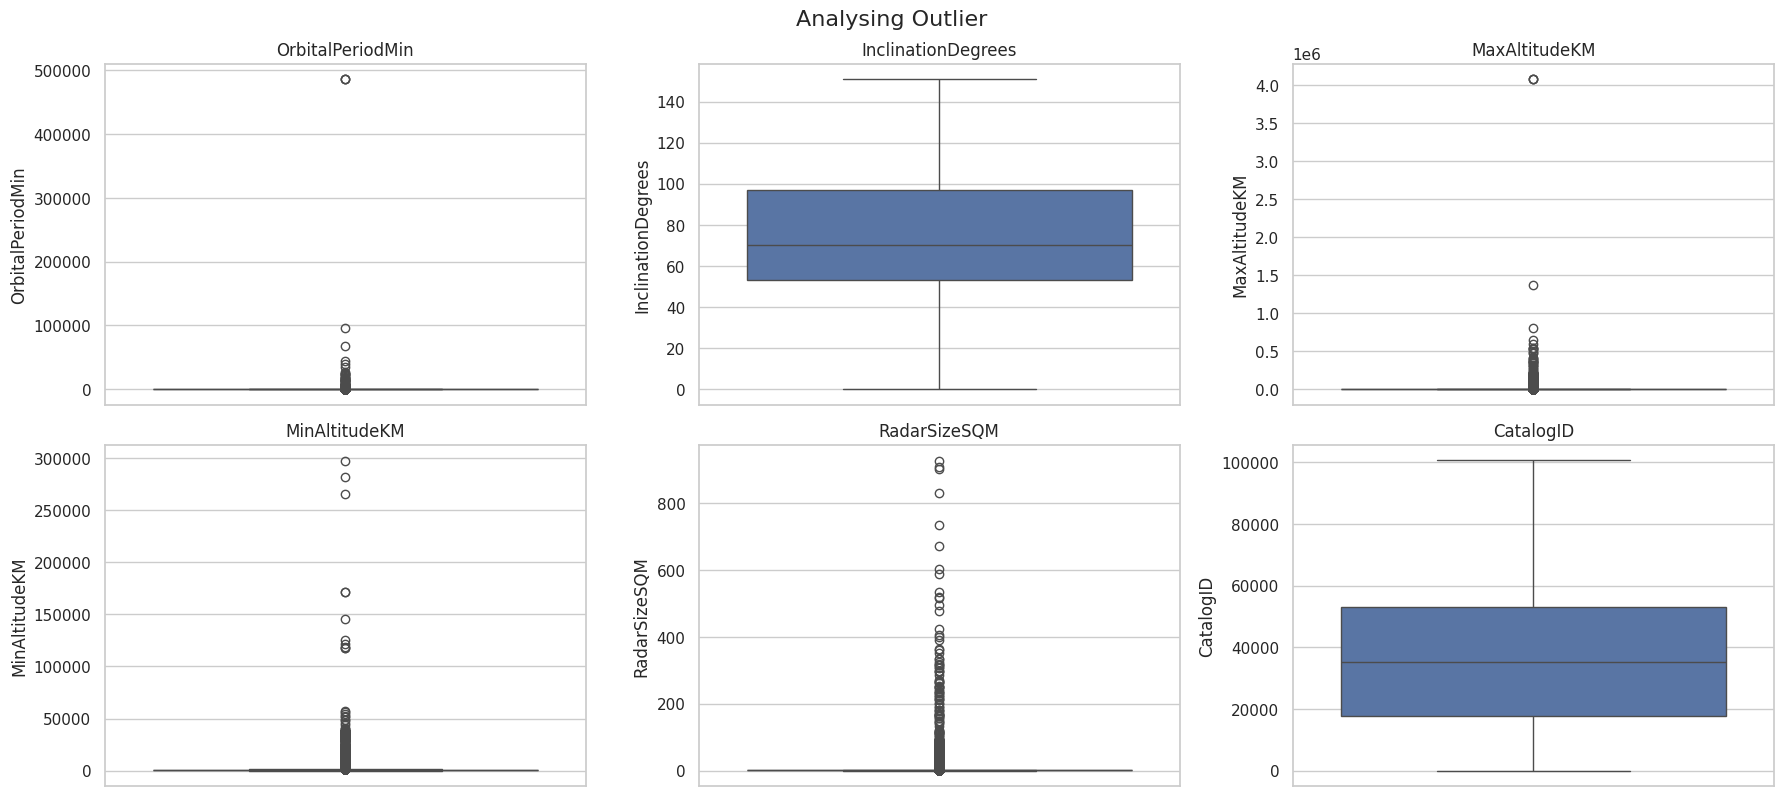

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# select only the numeric columns
num_col = df.select_dtypes(include=["number"])

# check lower quartile and upper quartile
Q1 = num_col.quantile(0.25)
Q3 = num_col.quantile(0.75)
IQR = Q3 - Q1

# checking lower and upper values
lower_value = Q1 - 1.5 * IQR
upper_value = Q3 + 1.5 * IQR

# Converting columns to Boolean so it will return True where an outlier exists
otlr = (num_col < lower_value) | (num_col > upper_value)

# Count total outliers per column
cnt_otlr = otlr.sum()
print("outlier_counts\n", cnt_otlr)

# if you want to see rows with outlier
rws_otlr = df[otlr.any(axis=1)]
print("Find outlier in Columns")
print(rws_otlr)
print("")

rws_otlr.head()

#  why Box plot not scatter plot because individual value checking not comparing for visualization
plt.figure(figsize=(18, 12))

plt.subplot(3,3,1)
sns.boxplot(y=df["OrbitalPeriodMin"])
plt.title('OrbitalPeriodMin')

plt.subplot(3,3,2)
sns.boxplot(y=df["InclinationDegrees"])
plt.title('InclinationDegrees')

plt.subplot(3,3,3)
sns.boxplot(y=df["MaxAltitudeKM"])
plt.title('MaxAltitudeKM')

plt.subplot(3,3,4)
sns.boxplot(y=df["MinAltitudeKM"])
plt.title('MinAltitudeKM')

plt.subplot(3,3,5)
sns.boxplot(y=df["RadarSizeSQM"])
plt.title('RadarSizeSQM')

plt.subplot(3,3,6)
sns.boxplot(y=df["CatalogID"])
plt.title('CatalogID')

plt.suptitle('Analysing Outlier', fontsize=16)
plt.tight_layout()
plt.show()

#### 4.1: Univariate Analysis (Distribution & Counts)
- Examine individual numeric distributions and categorical class breakdowns (e.g., Payload vs. Debris vs. Rocket Body).


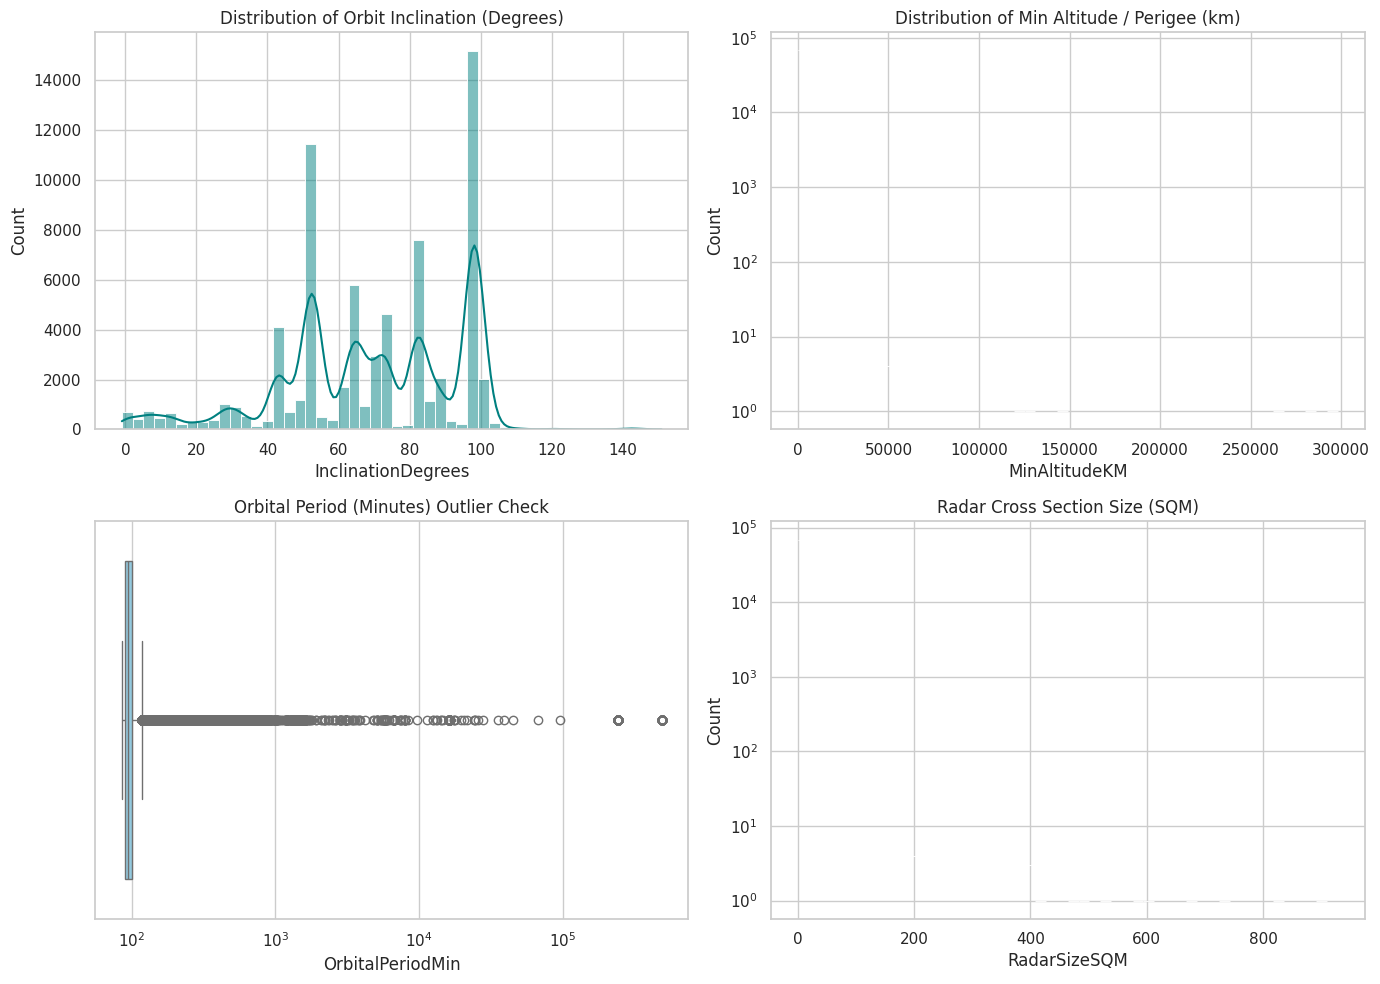

In [0]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of Inclination
sns.histplot(df['InclinationDegrees'].dropna(), bins=50, kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Distribution of Orbit Inclination (Degrees)')

# 2. Distribution of Min Altitude (Perigee) - Log Scale
sns.histplot(df['MinAltitudeKM'].dropna(), bins=50, log_scale=(False, True), ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Distribution of Min Altitude / Perigee (km)')

# 3. Boxplot for Orbital Period Outliers
sns.boxplot(x=df['OrbitalPeriodMin'], ax=axes[1, 0], color='skyblue')
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('Orbital Period (Minutes) Outlier Check')

# 4. Distribution of Radar Cross Section (Physical Size)
sns.histplot(df['RadarSizeSQM'].dropna(), bins=50, log_scale=(False, True), ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Radar Cross Section Size (SQM)')

plt.tight_layout()
plt.show()

## 4.2 Bivariate Analysis
We explore relationships between pairs of variables to detect orbital clusters (LEO, MEO, GEO) and compare metrics across object types.

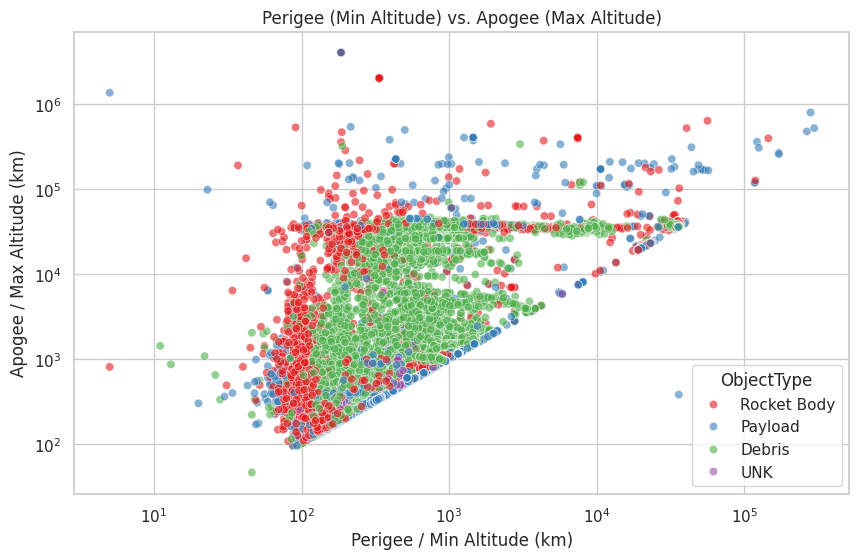

In [0]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='MinAltitudeKM', 
    y='MaxAltitudeKM', 
    hue='ObjectType', 
    alpha=0.6,
    palette='Set1'
)
plt.xscale('log')
plt.yscale('log')
plt.title('Perigee (Min Altitude) vs. Apogee (Max Altitude)')
plt.xlabel('Perigee / Min Altitude (km)')
plt.ylabel('Apogee / Max Altitude (km)')
plt.show()

## 4.3 Correlation & Crosstabulation
- We check for multicollinearity among numerical features and cross-examine categorical features.

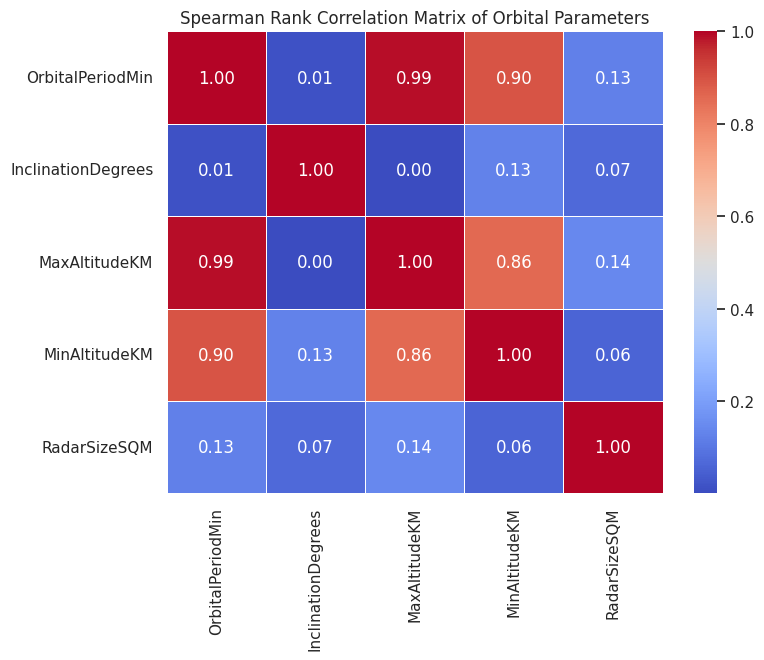

In [0]:
plt.figure(figsize=(8, 6))
numeric_cols = ['OrbitalPeriodMin', 'InclinationDegrees', 'MaxAltitudeKM', 'MinAltitudeKM', 'RadarSizeSQM']
corr_matrix = df[numeric_cols].corr(method='spearman')

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Spearman Rank Correlation Matrix of Orbital Parameters')
plt.show()

## 4.4 Historical Time-Series Analysis
- We analyze historical launch volume and object creation trends across decades using the datetime feature.

<Figure size 1200x600 with 0 Axes>

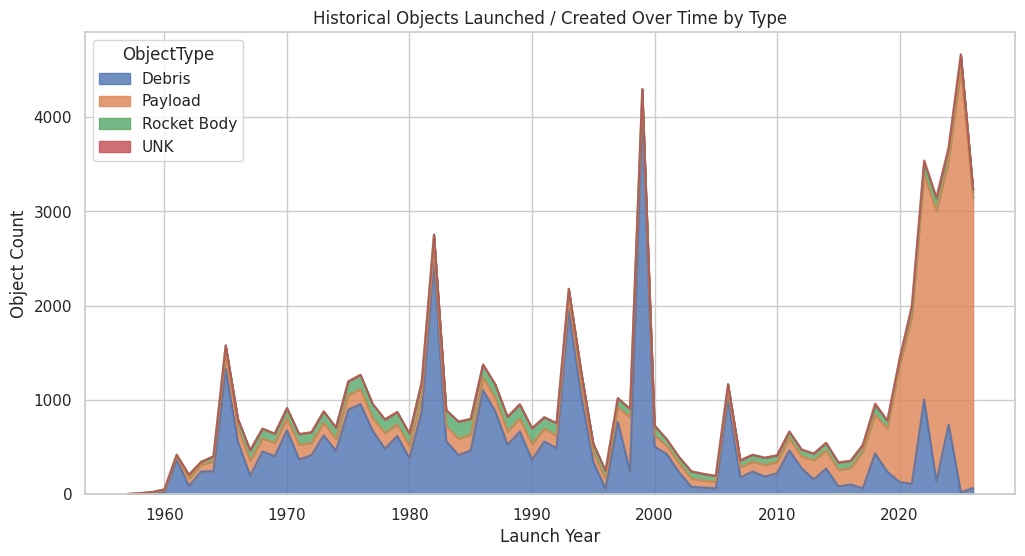

In [0]:
# Extract Launch Year
df['LaunchYear'] = df['LaunchDate'].dt.year

plt.figure(figsize=(12, 6))
df.groupby(['LaunchYear', 'ObjectType']).size().unstack(fill_value=0).plot(kind='area', stacked=True, figsize=(12, 6), alpha=0.8)
plt.title('Historical Objects Launched / Created Over Time by Type')
plt.xlabel('Launch Year')
plt.ylabel('Object Count')
plt.grid(True)
plt.show()

### EDA Analysis: Pivot Tables

In [0]:
# Create a pivot table for average orbital parameters by Object Type
grouped_pivot = df.groupby(['ObjectType', 'OrbitState'])[['OrbitalPeriodMin', 'MaxAltitudeKM']].mean().reset_index()
grouped_pivot_table = grouped_pivot.pivot(index='ObjectType', columns='OrbitState', values='MaxAltitudeKM')

# Display the pivot table
display(grouped_pivot_table)

Dock / Rendezvous (DOC),Impact (IMP),Lander (LAN),Orbiter (ORB)
null,518.9564025695931,255.0,5430.5545889864325
2771.8,3949.8132739668845,11733.345537757437,23257.039055472265
null,2030.5232974910393,null,110883.88875154512
null,288.1,null,752.3090909090909


### EDA Analysis: Correlation Matrix
*Raw correlation coefficients between numerical variables*

In [0]:
# 1. Select only the numerical columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# 2. Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# 3. Display the matrix
correlation_matrix

,CatalogID,OrbitalPeriodMin,InclinationDegrees,MaxAltitudeKM,MinAltitudeKM,RadarSizeSQM,IsDecayed,IsActive,IsDebris,IsRocketBody
CatalogID,1.000000,-0.020988,-0.007441,-0.025021,-0.026028,-0.079662,-0.436443,NaN,NaN,NaN
OrbitalPeriodMin,-0.020988,1.000000,-0.087449,0.996726,0.007127,-0.003395,-0.053618,NaN,NaN,NaN
InclinationDegrees,-0.007441,-0.087449,1.000000,-0.110714,-0.391534,-0.112720,0.087175,NaN,NaN,NaN
MaxAltitudeKM,-0.025021,0.996726,-0.110714,1.000000,0.036059,0.000080,-0.063745,NaN,NaN,NaN
MinAltitudeKM,-0.026028,0.007127,-0.391534,0.036059,1.000000,0.107458,-0.217884,NaN,NaN,NaN
RadarSizeSQM,-0.079662,-0.003395,-0.112720,0.000080,0.107458,1.000000,0.036888,NaN,NaN,NaN
IsDecayed,-0.436443,-0.053618,0.087175,-0.063745,-0.217884,0.036888,1.000000,NaN,NaN,NaN
IsActive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IsDebris,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IsRocketBody,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Note: Advanced Data Transformation Methods
**`.explode()`** - Turns lists into individual rows, temporarily duplicating row values so pandas can evaluate every item separately.
- Must be assigned to a variable (does not save changes automatically).

**`.melt()`**
- Converts a DataFrame from Wide Format (side-by-side columns) into Long Format (stacked rows). 
- **Example** of what I understood: think of months [January, February, March] as columns, then making one column as "Month" and adding all months like January, February, March as rows.
- Unpivots specified columns into key-value pairs (variable and value), repeating non-melted identifier columns for each row.
- Must be assigned to a variable (does not save changes automatically).


### EDA Analysis: Pearson Coefficient and P-Value

In [0]:
from scipy import stats

# Calculate the Pearson Coefficient and p-value between Max Altitude and Orbital Period
# (Make sure to drop any potential missing/null values just for this calculation)
clean_data = df.dropna(subset=['MaxAltitudeKM', 'OrbitalPeriodMin'])

pearson_coef, p_value = stats.pearsonr(clean_data['MaxAltitudeKM'], clean_data['OrbitalPeriodMin'])

print("Pearson Correlation Coefficient:", pearson_coef)
print("P-value:", p_value)

Pearson Correlation Coefficient: 0.9967260764175001
P-value: 0.0


## 8. Data Visualization

*Visual exploration of space debris data through charts, plots, and graphs*

### Visualization: Scatter Plot

### Visualization: Regression Plot

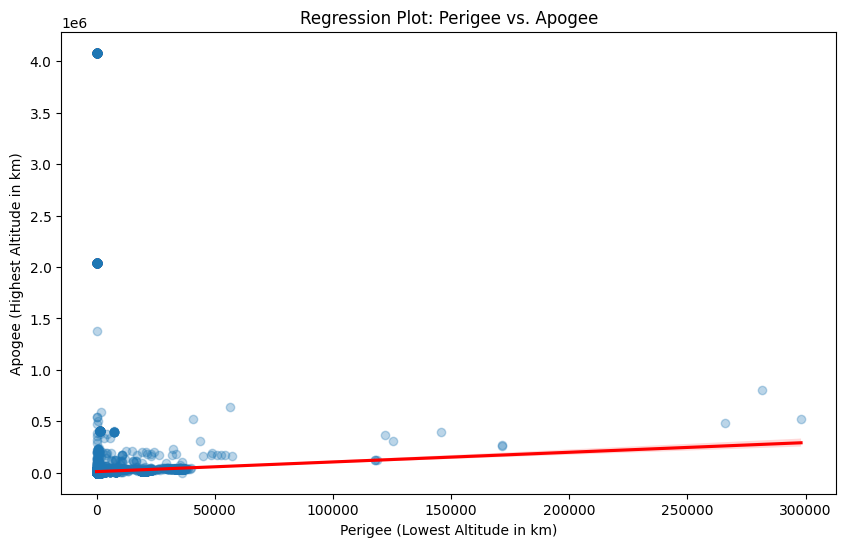

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Create the regression plot
# We use scatter_kws to make the dots transparent, and line_kws to make the trendline red
sns.regplot(x='MinAltitudeKM', y='MaxAltitudeKM', data=df, 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Regression Plot: Perigee vs. Apogee')
plt.xlabel('Perigee (Lowest Altitude in km)')
plt.ylabel('Apogee (Highest Altitude in km)')

plt.show()

### Visualization: Box Plot

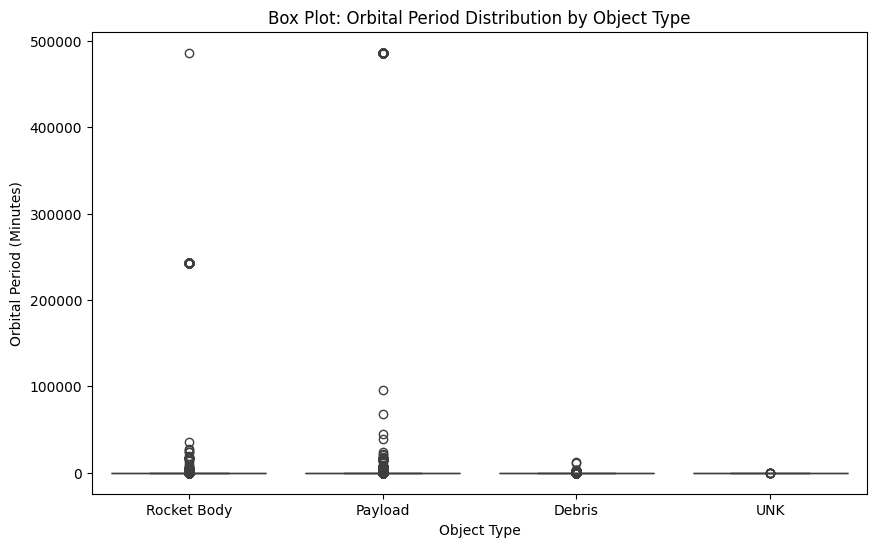

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Create the box plot
sns.boxplot(x='ObjectType', y='OrbitalPeriodMin', data=df)

plt.title('Box Plot: Orbital Period Distribution by Object Type')
plt.xlabel('Object Type')
plt.ylabel('Orbital Period (Minutes)')

plt.show()

### Visualization: Heatmap (Pseudocolor Plot)

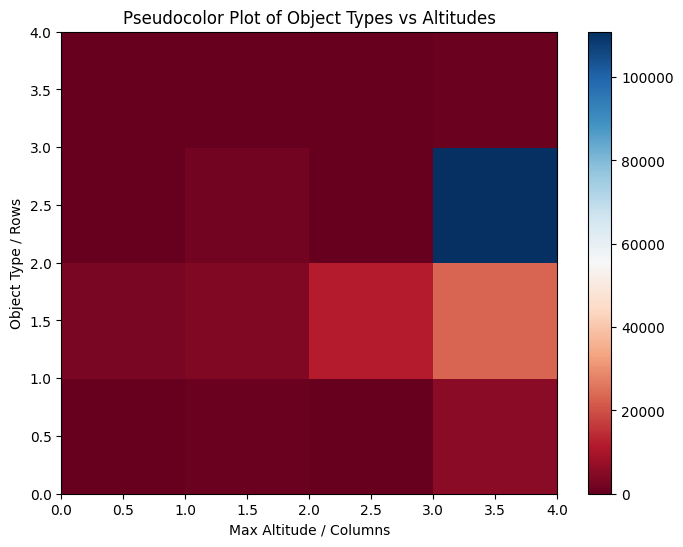

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Create the pseudocolor plot using our pivot table data
plt.pcolor(grouped_pivot_table.fillna(0), cmap='RdBu')

# Add labels and a color bar for reference
plt.title('Pseudocolor Plot of Object Types vs Altitudes')
plt.xlabel('Max Altitude / Columns')
plt.ylabel('Object Type / Rows')
plt.colorbar()

plt.show()

### Visualization: Count Plots - Categorical Distributions

/home/spark-0f4cb056-a0f6-449f-8d29-ac/.ipykernel/88/command-8818404137797495-187349966:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='ObjectType', ax=axes[0, 0], palette='Set2')
/home/spark-0f4cb056-a0f6-449f-8d29-ac/.ipykernel/88/command-8818404137797495-187349966:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='OperationalStatus', ax=axes[0, 1], palette='Set3')
/home/spark-0f4cb056-a0f6-449f-8d29-ac/.ipykernel/88/command-8818404137797495-187349966:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_owner

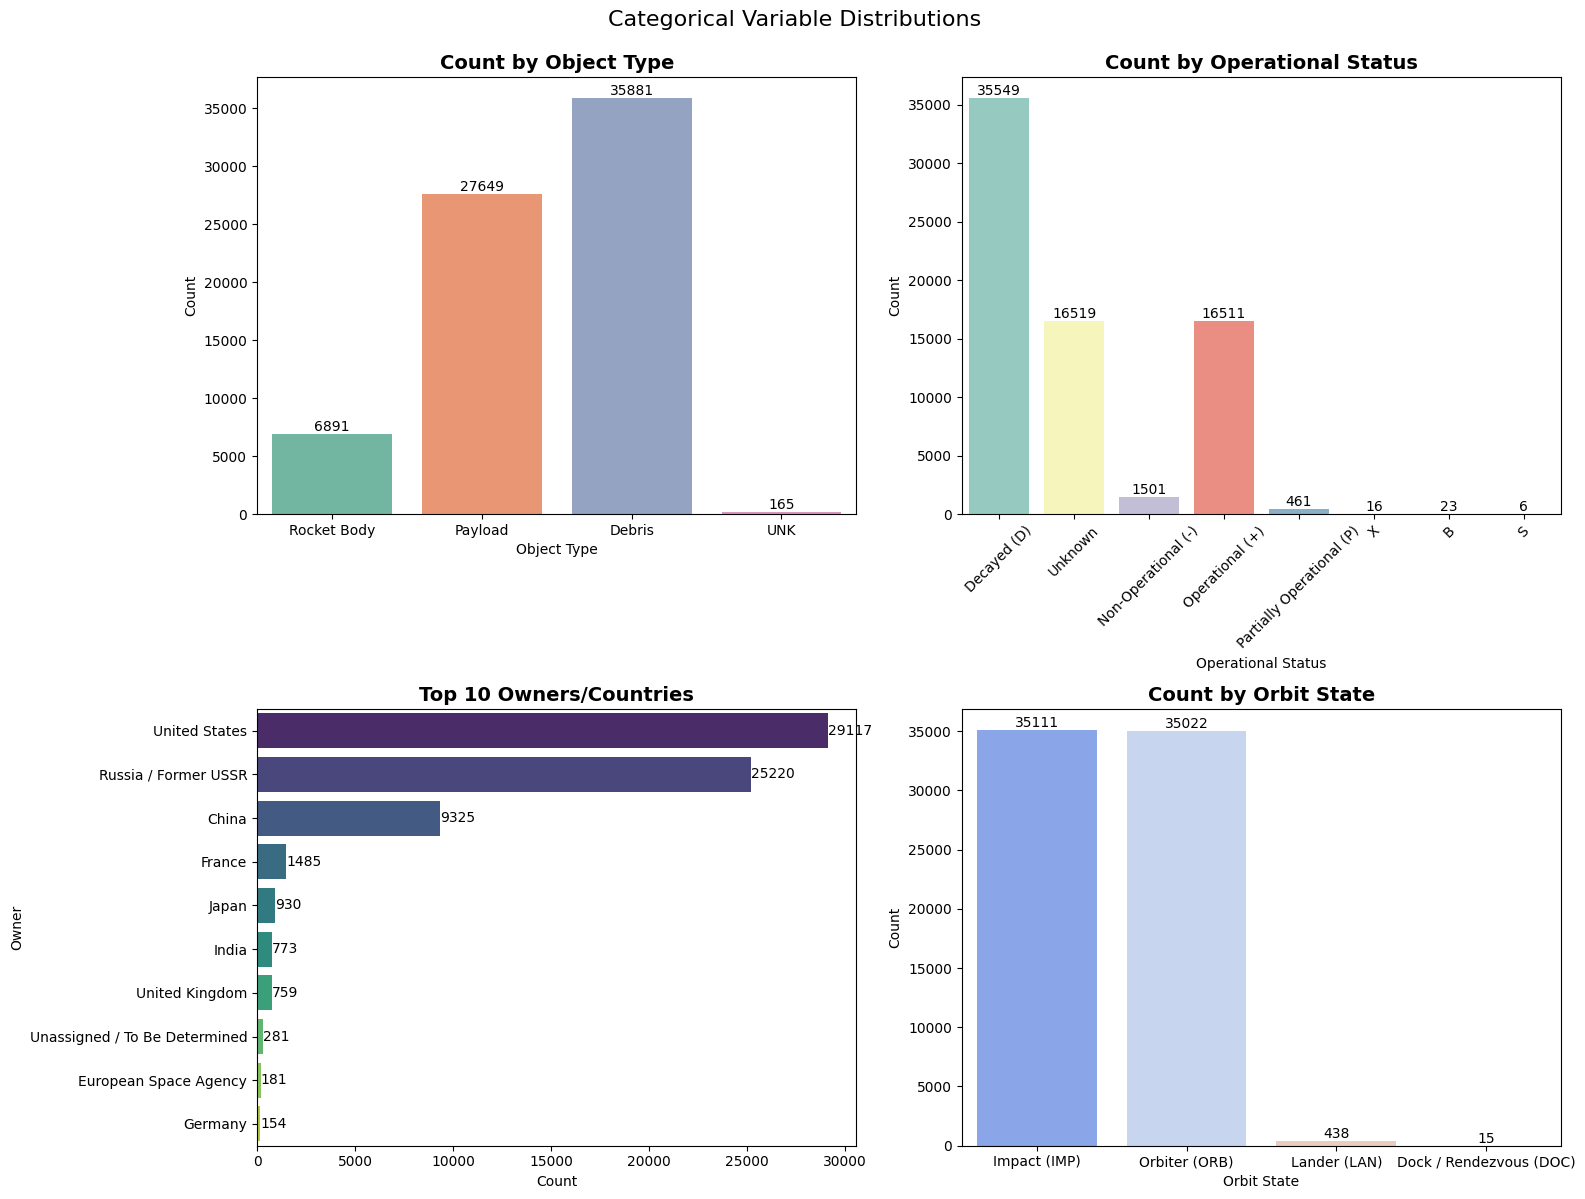

In [0]:
# Creating count plots for categorical variables
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Object Type
sns.countplot(data=df, x='ObjectType', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Count by Object Type', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Object Type')
axes[0, 0].set_ylabel('Count')
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container)

# Operational Status
sns.countplot(data=df, x='OperationalStatus', ax=axes[0, 1], palette='Set3')
axes[0, 1].set_title('Count by Operational Status', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Operational Status')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)
for container in axes[0, 1].containers:
    axes[0, 1].bar_label(container)

# Top 10 Owners
top_owners = df['Owner'].value_counts().head(10)
sns.barplot(x=top_owners.values, y=top_owners.index, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Top 10 Owners/Countries', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Count')
axes[1, 0].set_ylabel('Owner')
for container in axes[1, 0].containers:
    axes[1, 0].bar_label(container)

# Orbit State
sns.countplot(data=df, x='OrbitState', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('Count by Orbit State', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Orbit State')
axes[1, 1].set_ylabel('Count')
for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container)

plt.suptitle('Categorical Variable Distributions', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

### Visualization: Time Series - Launch Trends Over Time

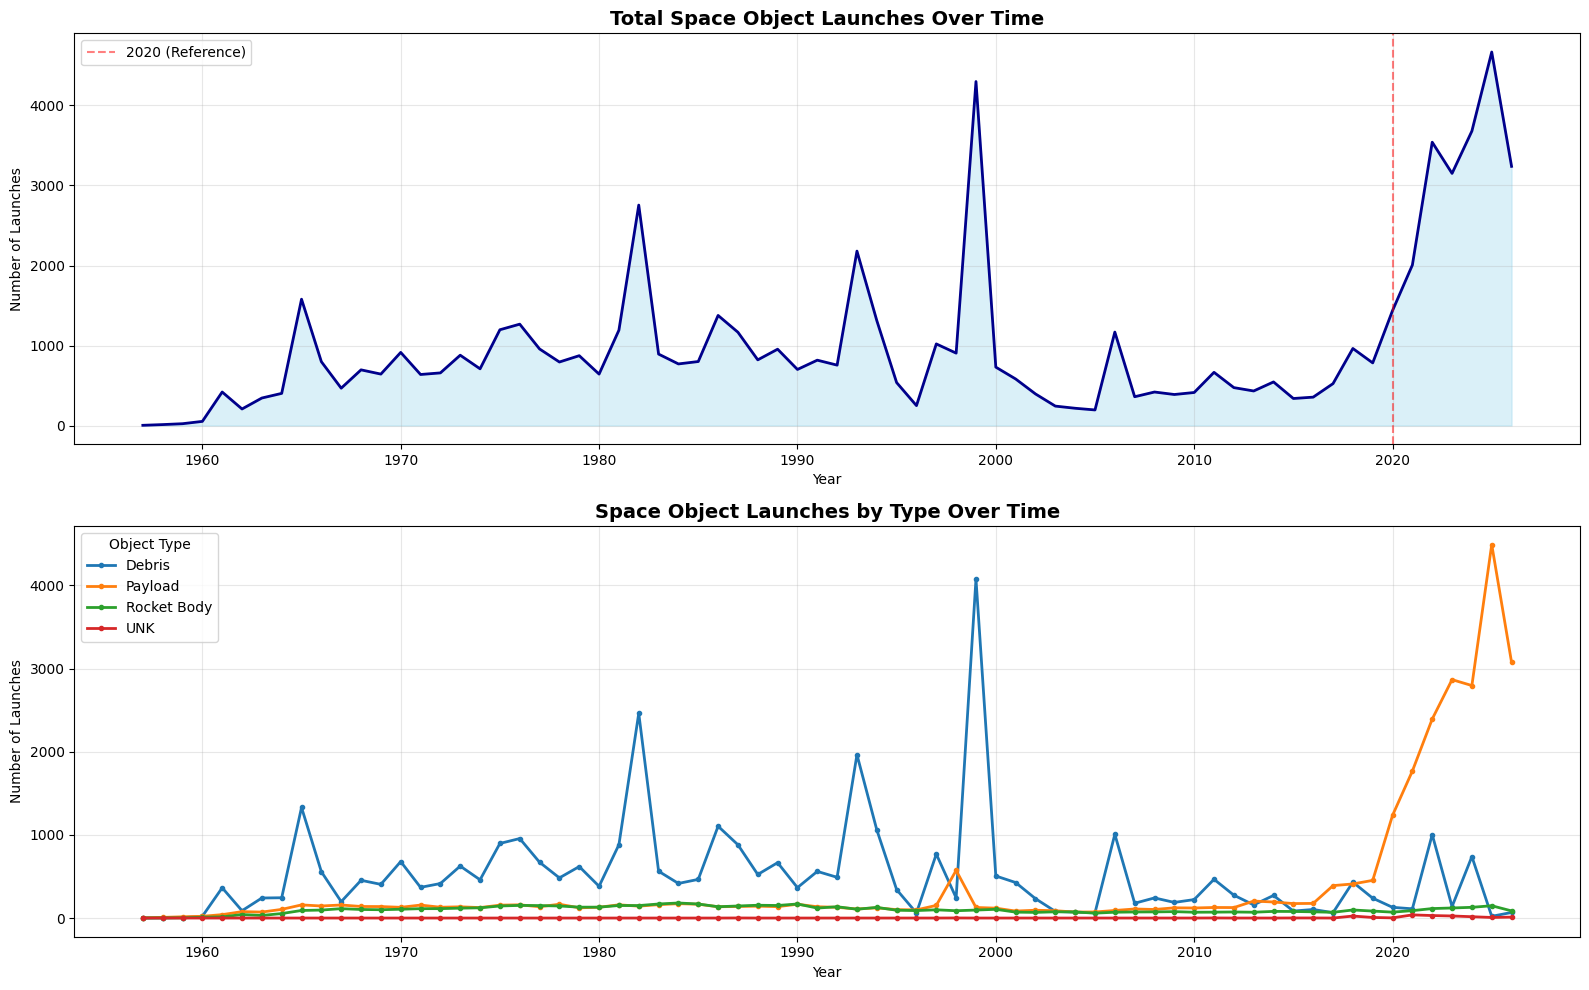


=== Launch Statistics ===
Total launches: 70,586
Peak year: 2025 with 4,668 launches
First launch: 1957
Latest launch: 2026


In [0]:
# Extract year from LaunchDate
df['LaunchYear'] = pd.to_datetime(df['LaunchDate']).dt.year

# Count launches per year
launches_per_year = df.groupby('LaunchYear').size()

# Create figure with subplots
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Overall launch trend
axes[0].plot(launches_per_year.index, launches_per_year.values, linewidth=2, color='darkblue')
axes[0].fill_between(launches_per_year.index, launches_per_year.values, alpha=0.3, color='skyblue')
axes[0].set_title('Total Space Object Launches Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Launches')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=2020, color='red', linestyle='--', alpha=0.5, label='2020 (Reference)')
axes[0].legend()

# Launch trend by Object Type
launches_by_type = df.groupby(['LaunchYear', 'ObjectType']).size().unstack(fill_value=0)
for obj_type in launches_by_type.columns:
    axes[1].plot(launches_by_type.index, launches_by_type[obj_type], linewidth=2, label=obj_type, marker='o', markersize=3)

axes[1].set_title('Space Object Launches by Type Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Launches')
axes[1].legend(title='Object Type')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n=== Launch Statistics ===")
print(f"Total launches: {len(df):,}")
print(f"Peak year: {launches_per_year.idxmax()} with {launches_per_year.max():,} launches")
print(f"First launch: {df['LaunchYear'].min()}")
print(f"Latest launch: {df['LaunchYear'].max()}")

### Visualization: Orbital Altitude Analysis

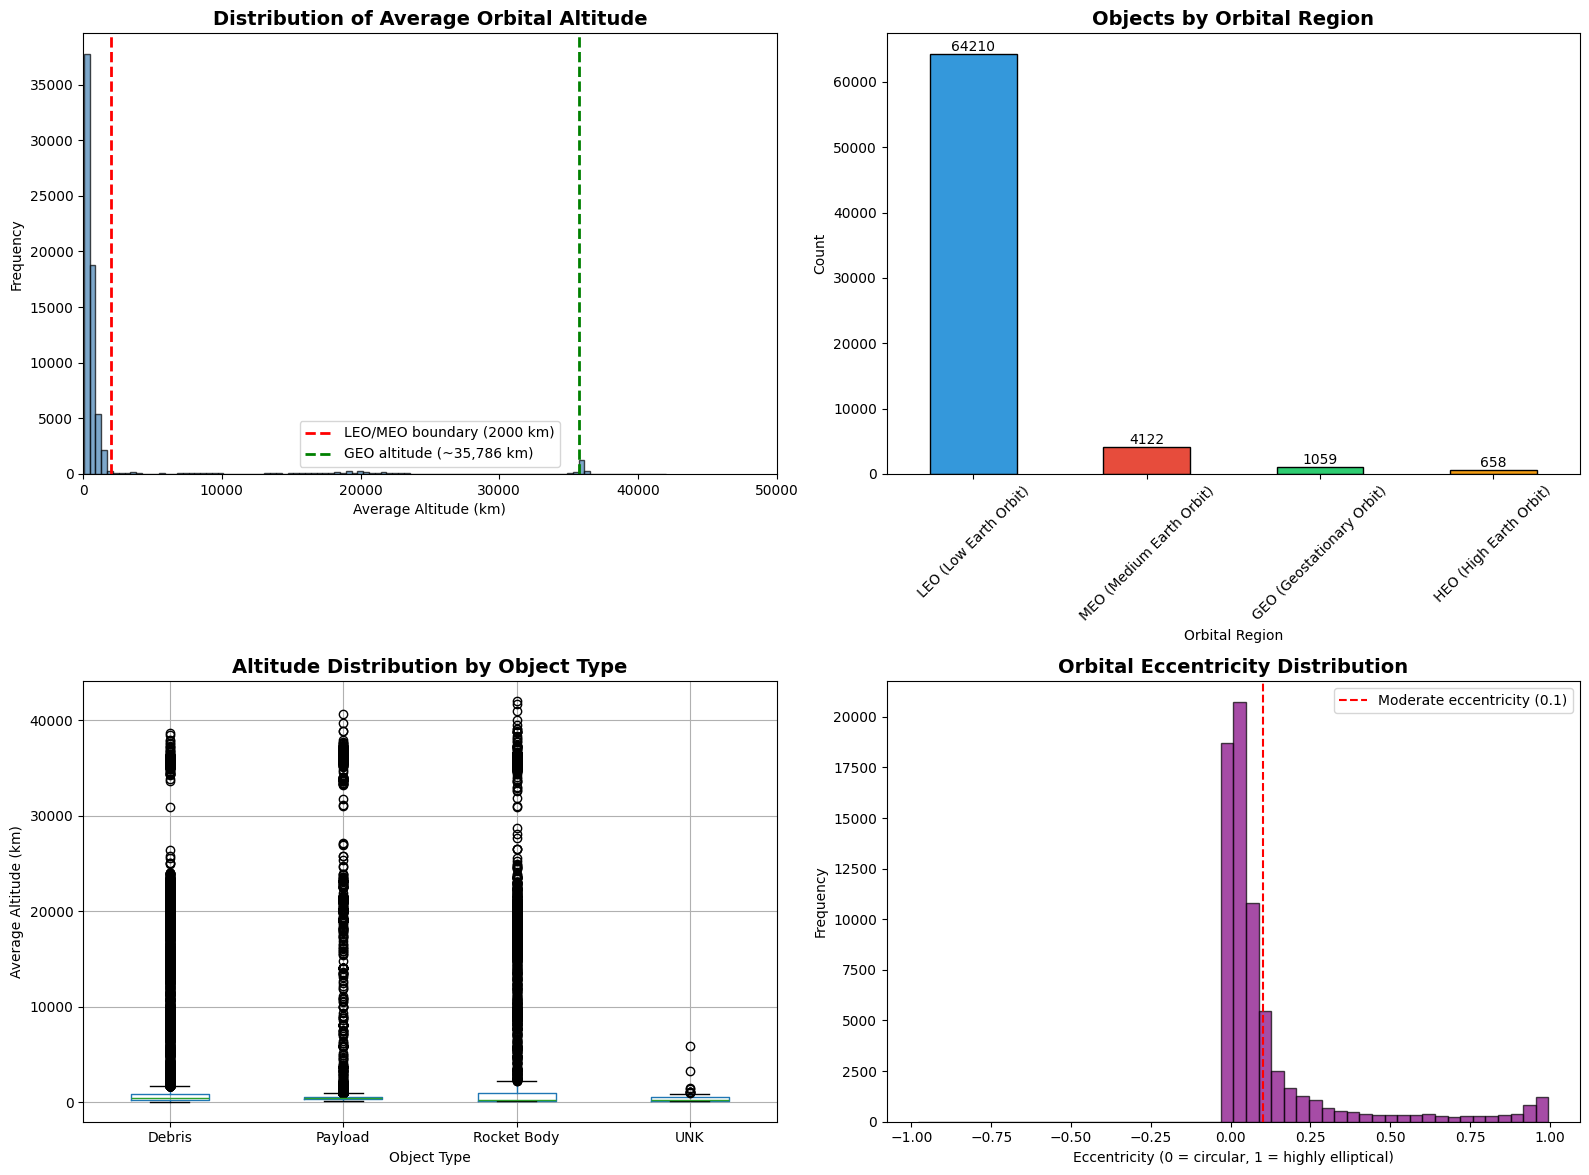

=== Orbital Altitude Statistics ===

Orbital Region Distribution:
  LEO (Low Earth Orbit): 64,210 (91.7%)
  MEO (Medium Earth Orbit): 4,122 (5.9%)
  GEO (Geostationary Orbit): 1,059 (1.5%)
  HEO (High Earth Orbit): 658 (0.9%)

Altitude Statistics (km):
  Mean: 2224.84
  Median: 463.00
  Min: 46.00
  Max: 42020.50


In [0]:
# Filter valid altitude data (exclude sentinel -1 values and extreme outliers)
df_orbits = df[(df['MaxAltitudeKM'] >= 0) & (df['MinAltitudeKM'] >= 0) & 
               (df['MaxAltitudeKM'] < 50000)].copy()

# Calculate average orbital altitude
df_orbits['AvgAltitudeKM'] = (df_orbits['MaxAltitudeKM'] + df_orbits['MinAltitudeKM']) / 2

# Define orbital regions
def classify_orbit(altitude):
    if altitude < 2000:
        return 'LEO (Low Earth Orbit)'
    elif altitude < 35586:
        return 'MEO (Medium Earth Orbit)'
    elif 35586 <= altitude <= 35986:
        return 'GEO (Geostationary Orbit)'
    else:
        return 'HEO (High Earth Orbit)'

df_orbits['OrbitRegion'] = df_orbits['AvgAltitudeKM'].apply(classify_orbit)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribution of average altitude
axes[0, 0].hist(df_orbits['AvgAltitudeKM'], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=2000, color='red', linestyle='--', linewidth=2, label='LEO/MEO boundary (2000 km)')
axes[0, 0].axvline(x=35786, color='green', linestyle='--', linewidth=2, label='GEO altitude (~35,786 km)')
axes[0, 0].set_title('Distribution of Average Orbital Altitude', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Average Altitude (km)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 50000)

# Objects by orbital region
orbit_counts = df_orbits['OrbitRegion'].value_counts()
orbit_counts.plot(kind='bar', ax=axes[0, 1], color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], edgecolor='black')
axes[0, 1].set_title('Objects by Orbital Region', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Orbital Region')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)
for container in axes[0, 1].containers:
    axes[0, 1].bar_label(container)

# Altitude by Object Type
df_orbits.boxplot(column='AvgAltitudeKM', by='ObjectType', ax=axes[1, 0])
axes[1, 0].set_title('Altitude Distribution by Object Type', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Object Type')
axes[1, 0].set_ylabel('Average Altitude (km)')
plt.sca(axes[1, 0])
plt.xticks(rotation=0)
axes[1, 0].get_figure().suptitle('')  # Remove default title

# Eccentricity analysis (orbital shape)
df_orbits['Eccentricity'] = (df_orbits['MaxAltitudeKM'] - df_orbits['MinAltitudeKM']) / (df_orbits['MaxAltitudeKM'] + df_orbits['MinAltitudeKM'])
axes[1, 1].hist(df_orbits['Eccentricity'], bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Orbital Eccentricity Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Eccentricity (0 = circular, 1 = highly elliptical)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(x=0.1, color='red', linestyle='--', label='Moderate eccentricity (0.1)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Print statistics
print("=== Orbital Altitude Statistics ===")
print(f"\nOrbital Region Distribution:")
for region, count in orbit_counts.items():
    print(f"  {region}: {count:,} ({count/len(df_orbits)*100:.1f}%)")

print(f"\nAltitude Statistics (km):")
print(f"  Mean: {df_orbits['AvgAltitudeKM'].mean():.2f}")
print(f"  Median: {df_orbits['AvgAltitudeKM'].median():.2f}")
print(f"  Min: {df_orbits['AvgAltitudeKM'].min():.2f}")
print(f"  Max: {df_orbits['AvgAltitudeKM'].max():.2f}")

# Phase 5: Feature Engineering & Preprocessing

## 4. Data Normalization / Feature Scaling

#### Note: Feature Scaling Not Applied 
- Feature scaling is not applied to this project as we not going to do any Machine learning part.

### When to Use Feature Scaling (For ML Modeling)

*Rescales continuous numerical features with large variations (e.g., altitudes reaching 36,000km vs. orbital periods of 90minutes) so algorithms treat them equally.*

* **`OrbitalPeriodMinutes`**
* **`InclinationDegrees`**
* **`ApogeeKM`**
* **`PerigeeKM`**
* **`RadarCrossSectionSQM`**



#### Note: Scaling Methods for ML

* **`RobustScaler`**
* **When to use:** When data has **heavy/extreme outliers**.
* **Formula:**
$$x_{\text{scaled}} = \frac{x - \text{Median}}{\text{IQR}}$$


*Where IQR = Q3 (75th percentile) - Q1 (25th percentile)*


* **`MinMaxScaler`**
* **When to use:** When we need a **values in [0, 1] range** and have **no outliers**.
* **Formula:**
$$x_{\text{scaled}} = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}$$




* **`StandardScaler`**
* **When to use:** When data follows a **bell curve (normal distribution)** with **few or no outliers**.
* **Formula:**
$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$


mean is $${\mu}$$ 
standard deviation is $$\sigma$$



---

### Code

```python
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

```

## 5. Data Binning (Categorical Grouping)

#### Note:

**When to Bin in Python**

* If you're building **machine learning models** → bin in Python
* If you're making **charts in Python** (matplotlib, seaborn, Plotly) → bin in Python
* If you have **fixed business rules** that never change → bin in Python

---

**When NOT to Bin (Let Power BI Do It)**

* If your **final dashboard is in Power BI** → don't bin in Python
* If you want **smaller file sizes** → don't bin in Python
* If users need to **change bin ranges** in the report → don't bin in Python
* If you need **exact numbers later** → don't bin in Python

#### Column: MaxAltitudeKM
* **-1 - 2000:** Low Earth Orbit (LEO)
* **2000 - 35785:** Medium Earth Orbit (MEO)
* **35785 - 36000:** Geostationary Earth Orbit (GEO)
* **36000 - np.inf:** High Earth Orbit (HEO)

In [0]:

# 1. Orbital Altitude Bins (ApogeeKM)
# low -1 to 2000, medium 2000 to 35785, geo 35785 to 36000, Heo 36000 to infinity (float('inf))
orbit_bins = [-1, 2000, 35785, 36000, np.inf]
orbit_labels = ['Low Earth Orbit', 'Medium Earth Orbit', 'Geostationary Orbit', 'High Earth Orbit']
df['OrbitClass'] = pd.cut(df['MaxAltitudeKM'], bins=orbit_bins, labels=orbit_labels)

df

,ObjectName,ObjectID,CatalogID,ObjectType,OperationalStatus,Owner,LaunchDate,LaunchSite,DecayDate,OrbitalPeriodMin,InclinationDegrees,MaxAltitudeKM,MinAltitudeKM,RadarSizeSQM,DataStatus,OrbitCenter,OrbitState,OrbitClass
0,SL-1 R/B,1957-001A,1,Rocket Body,Decayed (D),Russia / Former USSR,1957-10-04,Kazakhstan (TYMSC),1957-12-01,96.19,65.10,938.0,214.0,20.420,Active Tracking,Earth (EA),Impact (IMP),Low Earth Orbit
1,SPUTNIK 1,1957-001B,2,Payload,Decayed (D),Russia / Former USSR,1957-10-04,Kazakhstan (TYMSC),1958-01-03,96.10,65.00,1080.0,64.0,0.000,Active Tracking,Earth (EA),Impact (IMP),Low Earth Orbit
2,SPUTNIK 2,1957-002A,3,Payload,Decayed (D),Russia / Former USSR,1957-11-03,Kazakhstan (TYMSC),1958-04-14,103.74,65.33,1659.0,211.0,0.080,Active Tracking,Earth (EA),Impact (IMP),Low Earth Orbit
3,EXPLORER 1,1958-001A,4,Payload,Decayed (D),United States,1958-02-01,United States (AFETR),1970-03-31,88.48,33.15,215.0,183.0,0.000,Active Tracking,Earth (EA),Impact (IMP),Low Earth Orbit
4,VANGUARD 1,1958-002B,5,Payload,Unknown,United States,1958-03-17,United States (AFETR),NaT,132.59,34.24,3818.0,653.0,0.122,Active Tracking,Earth (EA),Orbiter (ORB),Medium Earth Orbit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70581,OBJECT B,2026-203B,100610,Payload,Operational (+),Unassigned / To Be Determined,2026-09-05,ANDSP,NaT,95.85,97.42,600.0,519.0,0.000,Active Tracking,Earth (EA),Orbiter (ORB),Low Earth Orbit
70582,OBJECT C,2026-203C,100611,Payload,Operational (+),Unassigned / To Be Determined,2026-09-05,ANDSP,NaT,95.84,97.41,601.0,517.0,0.000,Active Tracking,Earth (EA),Orbiter (ORB),Low Earth Orbit
70583,OBJECT D,2026-203D,100612,Payload,Operational (+),Unassigned / To Be Determined,2026-09-05,ANDSP,NaT,95.84,97.42,601.0,518.0,0.000,Active Tracking,Earth (EA),Orbiter (ORB),Low Earth Orbit
70584,OBJECT E,2026-203E,100613,Payload,Operational (+),Unassigned / To Be Determined,2026-09-05,ANDSP,NaT,95.84,97.42,600.0,519.0,0.000,Active Tracking,Earth (EA),Orbiter (ORB),Low Earth Orbit


#### Column: RadarCrossSectionSQM
* **-1 - 0.1**: Small
* **0.1 - 1.0**: Medium
* **1.0 - np.inf**: Large

In [0]:
# Column: RadarCrossSectionSQM

size_bins = [-1, 0.1, 1.0, np.inf]
size_labels = ['Small', 'Medium', 'Large']
df['RadarSize'] = pd.cut(df['RadarSizeSQM'], bins=size_bins, labels=size_labels)
df.head(4)

,ObjectName,ObjectID,CatalogID,ObjectType,OperationalStatus,Owner,LaunchDate,LaunchSite,DecayDate,OrbitalPeriodMin,InclinationDegrees,MaxAltitudeKM,MinAltitudeKM,RadarSizeSQM,DataStatus,OrbitCenter,OrbitState,OrbitClass,RadarSize
0,SL-1 R/B,1957-001A,1,Rocket Body,Decayed (D),Russia / Former USSR,1957-10-04,Kazakhstan (TYMSC),1957-12-01,96.19,65.10,938.0,214.0,20.42,Active Tracking,Earth (EA),Impact (IMP),Low Earth Orbit,Large
1,SPUTNIK 1,1957-001B,2,Payload,Decayed (D),Russia / Former USSR,1957-10-04,Kazakhstan (TYMSC),1958-01-03,96.10,65.00,1080.0,64.0,0.00,Active Tracking,Earth (EA),Impact (IMP),Low Earth Orbit,Small
2,SPUTNIK 2,1957-002A,3,Payload,Decayed (D),Russia / Former USSR,1957-11-03,Kazakhstan (TYMSC),1958-04-14,103.74,65.33,1659.0,211.0,0.08,Active Tracking,Earth (EA),Impact (IMP),Low Earth Orbit,Small
3,EXPLORER 1,1958-001A,4,Payload,Decayed (D),United States,1958-02-01,United States (AFETR),1970-03-31,88.48,33.15,215.0,183.0,0.00,Active Tracking,Earth (EA),Impact (IMP),Low Earth Orbit,Small


#### Column: LaunchDate
* **1980-1900:** *19th Century*
* **1900–2000:** *20th century*
* **2000–Present:** *21st century*

In [0]:
# Column: LaunchDate 

launch_bins = [1800, 1900, 2000, 2035]
launch_labels = ['19th Century', '20th Century', '21st Century']
df['LaunchEra'] = pd.cut(df['LaunchDate'].dt.year, bins=launch_bins, labels=launch_labels)

## 6. Creating Indicator Variables

### Binary Flags for Power BI

*Creates binary (1 or 0) flags to easily isolate specific conditions in Power BI measures or ML features.*

* **`IsDecayed`:** `1` if `DecayDate` is present (or `OrbitState == "IMP"`), `0` if still in orbit.
* **`IsActive`:** `1` if `OperationalStatus == "+"` (or `ObjectType == "PAY"` and `DecayDate` is null), `0` otherwise.
* **`IsDebris`:** `1` if `ObjectType == "DEB"`, `0` otherwise.
* **`IsRocketBody`:** `1` if `ObjectType == "R/B"`, `0` otherwise.



In [0]:
import numpy as np

# 1. IsDecayed: 1 if DecayDate is present or OrbitState is 'IMP', 0 if still in orbit
df["IsDecayed"] = np.where(df["DecayDate"].notna() | (df["OrbitState"] == "IMP"), 1, 0)

# 2. IsActive: 1 if OperationalStatus is '+' or (ObjectType is 'PAY' and DecayDate is NaT), 0 otherwise
df["IsActive"] = np.where((df["OperationalStatus"] == "+") | ((df["ObjectType"] == "PAY") & (df["DecayDate"].isna())), 1, 0)

# 3. IsDebris: 1 if ObjectType is 'DEB', 0 otherwise
df["IsDebris"] = np.where(df["ObjectType"] == "DEB", 1, 0)

# 4. IsRocketBody: 1 if ObjectType is 'R/B', 0 otherwise
df["IsRocketBody"] = np.where(df["ObjectType"] == "R/B", 1, 0)

# Display the newly created binary columns to verify
display(df[["ObjectName", "ObjectType", "IsDecayed", "IsActive", "IsDebris", "IsRocketBody"]].head(10))

ObjectName,ObjectType,IsDecayed,IsActive,IsDebris,IsRocketBody
SL-1 R/B,Rocket Body,1,0,0,0
SPUTNIK 1,Payload,1,0,0,0
SPUTNIK 2,Payload,1,0,0,0
EXPLORER 1,Payload,1,0,0,0
VANGUARD 1,Payload,0,0,0,0
EXPLORER 3,Payload,1,0,0,0
SL-1 R/B,Rocket Body,1,0,0,0
SPUTNIK 3,Payload,1,0,0,0
EXPLORER 4,Payload,1,0,0,0
SCORE,Payload,1,0,0,0


In [0]:
df.to_csv("/Workspace/Users/guruvendra47@gmail.com/Space-Debris-Project/raw/space_debris_cleaned.csv", index=False)
